In [1]:
import subprocess, sys
for _pkg in ["optuna","yfinance","ta","vaderSentiment",
             "xgboost","lightgbm","shap","scikit-learn",
             "tensorflow","statsmodels","seaborn"]:
    subprocess.check_call([sys.executable,"-m","pip","install",_pkg,"-q"],
                          stdout=subprocess.DEVNULL,stderr=subprocess.DEVNULL)

IMPORTS
Loads all required libraries and defines global parameters used throughout the notebook

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker, matplotlib.dates as mdates
import matplotlib.patches as mpatches, seaborn as sns
import warnings, os, json
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

SEED = 42; np.random.seed(SEED)

import yfinance as yf
from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (accuracy_score, f1_score, precision_score,
                                      recall_score, roc_auc_score,
                                      confusion_matrix, RocCurveDisplay)
import xgboost  as xgb
import lightgbm as lgb
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

import tensorflow as tf; tf.get_logger().setLevel("ERROR")
tf.random.set_seed(SEED)
from tensorflow.keras.models     import Sequential
from tensorflow.keras.layers     import (LSTM as KerasLSTM, Dense,
                                          Dropout, BatchNormalization)
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from ta.momentum   import (RSIIndicator, StochasticOscillator,
                            WilliamsRIndicator, ROCIndicator)
from ta.trend      import MACD, SMAIndicator, EMAIndicator, ADXIndicator
from ta.volatility import AverageTrueRange, BollingerBands

plt.rcParams.update({"figure.dpi":120,"font.size":10})
os.makedirs("outputs", exist_ok=True)

START_DATE  = "2018-01-01"
END_DATE    = "2024-12-31"
TICKER      = "BTC-USD"
BTC_CSV     = "btc_raw.csv"
BENCH_ACC   = 0.8244
RED         = "#CC2200"
GRAY        = "#888888"
N_SPLITS_CV = 5
N_TRIALS    = 300

In [3]:
if os.path.exists(BTC_CSV):
    df_btc = pd.read_csv(BTC_CSV, index_col=0, parse_dates=True)
else:
    df_btc = yf.download(TICKER, start=START_DATE, end=END_DATE,
                         auto_adjust=True, progress=False)
    if df_btc.columns.nlevels > 1:
        df_btc.columns = df_btc.columns.get_level_values(0)
    df_btc.index = pd.to_datetime(df_btc.index).tz_localize(None)
    df_btc.to_csv(BTC_CSV)

df_btc["LogReturn"] = np.log(df_btc["Close"] / df_btc["Close"].shift(1))
df_btc["Direction"] = (df_btc["LogReturn"] > 0).astype(int)

In [4]:
FG_CSV = "feargreed_raw.csv"

fg = (
    pd.read_csv(FG_CSV)
    .assign(date=lambda x: pd.to_datetime(x["date"]).dt.normalize())
    .pipe(lambda x: x[(x["date"] >= START_DATE) & (x["date"] <= END_DATE)])
    .sort_values("date")
    .set_index("date")
    .copy()
)

fg["FG_sentiment"] = fg["sentiment_fg"].ffill()

In [5]:
VADER_CSV_IN  = "bitcoin_sentiments_21_24.csv"
VADER_CSV_OUT = "vader_daily.csv"

if os.path.exists(VADER_CSV_OUT):
    daily_vader = pd.read_csv(VADER_CSV_OUT, index_col=0, parse_dates=True)
else:
    news = pd.read_csv(VADER_CSV_IN)
    news["Date"] = pd.to_datetime(news["Date"], errors="coerce").dt.normalize()
    news = news.dropna(subset=["Date", "Short Description"])
    news = news[news["Short Description"].astype(str).str.strip() != ""]

    analyzer = SentimentIntensityAnalyzer()
    news["vader_compound"] = news["Short Description"].apply(
        lambda t: analyzer.polarity_scores(str(t))["compound"]
    )

    daily_vader = (
        news.groupby("Date")["vader_compound"]
        .agg(VADER_sentiment="mean", VADER_count="count")
    )
    daily_vader.index.name = "date"
    daily_vader.to_csv(VADER_CSV_OUT)

In [6]:
df = df_btc[["Open","High","Low","Close","Volume",
             "LogReturn","Direction"]].copy()

df = df.join(fg[["FG_sentiment"]], how="left")
df["FG_sentiment"] = df["FG_sentiment"].ffill()

In [7]:
from scipy import stats

# ── Drop NaN (first LogReturn) ────────────────────────────────
_before = len(df_btc)
df_btc  = df_btc.dropna()

# ── Overview ──────────────────────────────────────────────────
print(f"Shape      : {df_btc.shape}")
print(f"Date range : {df_btc.index[0].date()} → {df_btc.index[-1].date()}")
print(f"Columns    : {df_btc.columns.tolist()}")

# ── Missing & Duplicates ──────────────────────────────────────
print(f"\nMissing    : {df_btc.isnull().sum().sum()}")
print(f"Duplicates : {df_btc.index.duplicated().sum()}")
print(f"Dropped    : {_before - len(df_btc)} rows (first LogReturn NaN)")

# ── Time Gaps ─────────────────────────────────────────────────
_gaps = df_btc.index.to_series().diff().dt.days.dropna()
print(f"\nTime gaps > 1 day : {(_gaps > 1).sum()}")
print(f"Max gap           : {int(_gaps.max())} days")

# ── Outliers ──────────────────────────────────────────────────
_z = np.abs(stats.zscore(df_btc[["Close","LogReturn","Volume"]]))
_out = (_z > 3).any(axis=1).sum()
print(f"\nOutliers (|Z|>3)  : {_out} rows ({_out/len(df_btc):.1%})")
print(f"  → retained (real market events: COVID-19, FTX collapse)")

# ── Data Types Validation ─────────────────────────────────────
assert df_btc.index.dtype == "datetime64[ns]", "Index not datetime"
assert df_btc["Direction"].isin([0,1]).all(),   "Direction not binary"
assert (df_btc["Volume"] > 0).all(),            "Volume contains zeros"
print(f"\nData types OK ✓")

# ── Describe ──────────────────────────────────────────────────
print(f"\n── Descriptive Statistics ────────────────────────────")
print(df_btc[["Close","High","Low","Open","Volume",
              "LogReturn","Direction"]].describe().round(4))

Shape      : (2555, 7)
Date range : 2018-01-02 → 2024-12-30
Columns    : ['Close', 'High', 'Low', 'Open', 'Volume', 'LogReturn', 'Direction']

Missing    : 0
Duplicates : 0
Dropped    : 1 rows (first LogReturn NaN)

Time gaps > 1 day : 0
Max gap           : 1 days

Outliers (|Z|>3)  : 94 rows (3.7%)
  → retained (real market events: COVID-19, FTX collapse)

Data types OK ✓

── Descriptive Statistics ────────────────────────────
             Close         High          Low         Open        Volume  \
count    2555.0000    2555.0000    2555.0000    2555.0000  2.555000e+03   
mean    28065.7093   28656.5375   27386.5662   28036.5484  2.696024e+10   
std     22108.6353   22562.9588   21577.5608   22075.7670  1.965744e+10   
min      3236.7617    3275.3779    3191.3035    3236.2747  2.923670e+09   
25%      8964.9292    9201.8716    8790.9863    8940.4429  1.380982e+10   
50%     22206.7930   22613.6855   21460.0879   22156.4062  2.406287e+10   
75%     42841.0664   43584.7246   41909.259

In [8]:
# ── Cleaning ──────────────────────────────────────────────────
_missing_before = fg["FG_sentiment"].isna().sum()
fg["FG_sentiment"] = fg["sentiment_fg"].ffill()
fg = fg.drop(columns=["sentiment_fg"])
_missing_after = fg["FG_sentiment"].isna().sum()

# ── Overview ──────────────────────────────────────────────────
print(f"Shape      : {fg.shape}")
print(f"Date range : {fg.index[0].date()} → {fg.index[-1].date()}")
print(f"Columns    : {fg.columns.tolist()}")

# ── Missing & Duplicates ──────────────────────────────────────
print(f"\nMissing before ffill : {_missing_before}")
print(f"Missing after ffill  : {_missing_after}")
print(f"Duplicate dates      : {fg.index.duplicated().sum()}")

# ── Time Gaps ─────────────────────────────────────────────────
_gaps = fg.index.to_series().diff().dt.days.dropna()
print(f"\nTime gaps > 1 day : {(_gaps > 1).sum()}")
print(f"Max gap           : {int(_gaps.max())} days")

# ── Outliers ──────────────────────────────────────────────────
_z   = np.abs(stats.zscore(fg[["FG_sentiment","value"]]))
_out = (_z > 3).any(axis=1).sum()
print(f"\nOutliers (|Z|>3)  : {_out} rows ({_out/len(fg):.1%})")

# ── Data Types Validation ─────────────────────────────────────
assert fg.index.dtype == "datetime64[ns]", "Index not datetime"
assert fg["FG_sentiment"].between(-1, 1).all(), "FG_sentiment out of range"
print(f"Data types OK ✓")

# ── Describe ──────────────────────────────────────────────────
print(f"\n── Descriptive Statistics ────────────────────────────")
print(fg[["FG_sentiment","value","value_classification"]
         ].describe(include="all").round(4))

Shape      : (2522, 3)
Date range : 2018-02-01 → 2024-12-31
Columns    : ['value', 'value_classification', 'FG_sentiment']

Missing before ffill : 0
Missing after ffill  : 0
Duplicate dates      : 0

Time gaps > 1 day : 2
Max gap           : 4 days

Outliers (|Z|>3)  : 0 rows (0.0%)
Data types OK ✓

── Descriptive Statistics ────────────────────────────
        FG_sentiment      value value_classification
count      2522.0000  2522.0000                 2522
unique           NaN        NaN                    5
top              NaN        NaN                 Fear
freq             NaN        NaN                  740
mean         -0.0613    46.9326                  NaN
std           0.4395    21.9749                  NaN
min          -0.9000     5.0000                  NaN
25%          -0.4600    27.0000                  NaN
50%          -0.0800    46.0000                  NaN
75%           0.3200    66.0000                  NaN
max           0.9000    95.0000                  NaN


In [9]:
# ── Cleaning Stats ────────────────────────────────────────────
_raw     = pd.read_csv(VADER_CSV_IN)
_before  = len(_raw)
_raw["Date"] = pd.to_datetime(_raw["Date"], errors="coerce").dt.normalize()
_invalid = _raw["Date"].isna().sum()
_empty   = (_raw["Short Description"].astype(str).str.strip() == "").sum()
_clean   = _before - _invalid - _empty

# ── Overview ──────────────────────────────────────────────────
print(f"Shape      : {daily_vader.shape}")
print(f"Date range : {daily_vader.index[0].date()} → "
      f"{daily_vader.index[-1].date()}")
print(f"Columns    : {daily_vader.columns.tolist()}")

# ── Missing & Duplicates ──────────────────────────────────────
print(f"\nRaw headlines          : {_before:,}")
print(f"Invalid dates dropped  : {_invalid}")
print(f"Empty headlines dropped: {_empty}")
print(f"Clean headlines used   : {_clean:,}")
print(f"Daily aggregates       : {len(daily_vader):,} days")
print(f"Duplicate dates        : {daily_vader.index.duplicated().sum()}")
print(f"Missing values         : {daily_vader.isnull().sum().sum()}")

# ── Time Gaps ─────────────────────────────────────────────────
_gaps = daily_vader.index.to_series().diff().dt.days.dropna()
print(f"\nTime gaps > 1 day : {(_gaps > 1).sum()}")
print(f"Max gap           : {int(_gaps.max())} days")

# ── Outliers ──────────────────────────────────────────────────
_z   = np.abs(stats.zscore(daily_vader[["VADER_sentiment"]]))
_out = (_z > 3).any(axis=1).sum()
print(f"\nOutliers (|Z|>3)  : {_out} rows ({_out/len(daily_vader):.1%})")

# ── Data Types Validation ─────────────────────────────────────
assert daily_vader.index.dtype == "datetime64[ns]", "Index not datetime"
assert daily_vader["VADER_sentiment"].between(-1, 1).all(), \
       "VADER_sentiment out of range"
print(f"Data types OK ✓")

# ── Describe ──────────────────────────────────────────────────
print(f"\n── Descriptive Statistics ────────────────────────────")
print(daily_vader[["VADER_sentiment","VADER_count"]].describe().round(4))

Shape      : (887, 2)
Date range : 2021-11-05 → 2024-09-12
Columns    : ['VADER_sentiment', 'VADER_count']

Raw headlines          : 11,295
Invalid dates dropped  : 0
Empty headlines dropped: 0
Clean headlines used   : 11,295
Daily aggregates       : 887 days
Duplicate dates        : 0
Missing values         : 0

Time gaps > 1 day : 30
Max gap           : 72 days

Outliers (|Z|>3)  : 14 rows (1.6%)
Data types OK ✓

── Descriptive Statistics ────────────────────────────
       VADER_sentiment  VADER_count
count         887.0000     887.0000
mean            0.1202      12.7339
std             0.1667       7.2827
min            -0.7351       1.0000
25%             0.0168       6.0000
50%             0.1087      13.0000
75%             0.2112      18.0000
max             0.7906      34.0000


In [10]:
# ── Overview ──────────────────────────────────────────────────
print(f"Shape      : {df.shape}")
print(f"Date range : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Columns    : {df.columns.tolist()}")
print(f"Missing    : {df.isnull().sum().sum()}")
print(f"Duplicates : {df.index.duplicated().sum()}")

# ── F&G Coverage ──────────────────────────────────────────────
_fg_nan = df["FG_sentiment"].isna().sum()
print(f"\nF&G coverage   : {df['FG_sentiment'].notna().sum()} / "
      f"{len(df)} days ({df['FG_sentiment'].notna().mean():.1%})")
print(f"F&G NaN (before FG start): {_fg_nan}")

# ── Class Balance ─────────────────────────────────────────────
_up = df["Direction"].sum()
_dn = len(df) - _up
print(f"\nClass Balance:")
print(f"  Up days  : {_up:,} ({_up/len(df):.1%})")
print(f"  Down days: {_dn:,} ({_dn/len(df):.1%})")
print(f"  Imbalance ratio: {_up/len(df):.4f}")

# ── Target Distribution over Time ─────────────────────────────
print(f"\nUp-Day % per Year:")
print(df.groupby(df.index.year)["Direction"]
      .mean().apply(lambda x: f"{x:.1%}").to_string())

# ── Correlation: Sentiment → Direction ────────────────────────
print(f"\nCorrelation FG_sentiment → Direction: "
      f"{df['FG_sentiment'].corr(df['Direction']):+.4f}")

# ── Describe ──────────────────────────────────────────────────
print(f"\n── Descriptive Statistics ────────────────────────────")
print(df[["Close","LogReturn","Direction",
          "FG_sentiment"]].describe().round(4))

Shape      : (2556, 8)
Date range : 2018-01-01 → 2024-12-30
Columns    : ['Open', 'High', 'Low', 'Close', 'Volume', 'LogReturn', 'Direction', 'FG_sentiment']
Missing    : 32
Duplicates : 0

F&G coverage   : 2525 / 2556 days (98.8%)
F&G NaN (before FG start): 31

Class Balance:
  Up days  : 1,312 (51.3%)
  Down days: 1,244 (48.7%)
  Imbalance ratio: 0.5133

Up-Day % per Year:
Date
2018    51.0%
2019    52.3%
2020    56.3%
2021    51.2%
2022    46.6%
2023    49.9%
2024    52.1%

Correlation FG_sentiment → Direction: +0.0124

── Descriptive Statistics ────────────────────────────
             Close  LogReturn  Direction  FG_sentiment
count    2556.0000  2555.0000  2556.0000     2525.0000
mean    28060.0721     0.0007     0.5133       -0.0619
std     22106.1455     0.0357     0.4999        0.4396
min      3236.7617    -0.4647     0.0000       -0.9000
25%      8975.9895    -0.0139     0.0000       -0.4600
50%     22185.3711     0.0008     1.0000       -0.0800
75%     42840.4082     0.0161  

In [11]:
# Momentum (7)
df["RSI"]     = RSIIndicator(df["Close"], 14).rsi()
_sto          = StochasticOscillator(df["High"],df["Low"],df["Close"],14,3)
df["Stoch_K"] = _sto.stoch()
df["Stoch_D"] = _sto.stoch_signal()
df["WillR"]   = WilliamsRIndicator(df["High"],df["Low"],df["Close"],14).williams_r()
df["ROC_5"]   = ROCIndicator(df["Close"],  5).roc()
df["ROC_10"]  = ROCIndicator(df["Close"], 10).roc()
df["ROC_21"]  = ROCIndicator(df["Close"], 21).roc()

# Trend (5)
_m                = MACD(df["Close"])
df["MACD"]        = _m.macd()
df["MACD_Signal"] = _m.macd_signal()
df["MACD_Hist"]   = _m.macd_diff()
_ma7              = SMAIndicator(df["Close"],  7).sma_indicator()
_ma30             = SMAIndicator(df["Close"], 30).sma_indicator()
_ema12            = EMAIndicator(df["Close"], 12).ema_indicator()
_ema26            = EMAIndicator(df["Close"], 26).ema_indicator()
df["MA_Ratio"]    = _ma7  / _ma30
df["EMA_Ratio"]   = _ema12 / _ema26

# Volatility (6)
df["Vol_7"]     = df["LogReturn"].rolling(7).std()
df["Vol_30"]    = df["LogReturn"].rolling(30).std()
df["Vol_Ratio"] = df["Vol_7"] / df["Vol_30"]
df["ATR"]       = AverageTrueRange(df["High"],df["Low"],df["Close"],14).average_true_range()
_bb             = BollingerBands(df["Close"],20,2)
df["BB_pct"]    = _bb.bollinger_pband()
df["BB_width"]  = _bb.bollinger_wband()

# ADX (3)
_adx           = ADXIndicator(df["High"],df["Low"],df["Close"],14)
df["ADX"]      = _adx.adx()
df["ADX_pos"]  = _adx.adx_pos()
df["ADX_neg"]  = _adx.adx_neg()

# Lagged Returns (8)
for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
    df[f"Ret_L{lag}"] = df["LogReturn"].shift(lag)

# Price Ratios (2) — inline lag
df["Price_MA7"]  = (df["Close"] / _ma7).shift(1)
df["Price_MA30"] = (df["Close"] / _ma30).shift(1)

# Volume (5)
df["Vol_change"]  = df["Volume"].pct_change()
df["Vol_ratio7"]  = df["Volume"] / df["Volume"].rolling(7).mean()
df["Vol_ratio30"] = df["Volume"] / df["Volume"].rolling(30).mean()
df["Vol_spike"]   = ((df["Volume"] - df["Volume"].rolling(30).mean())
                     / df["Volume"].rolling(30).std())
df["Vol_spike_7"] = ((df["Volume"] - df["Volume"].rolling(7).mean())
                     / df["Volume"].rolling(7).std())

# Calendar (3)
df["DayOfWeek"] = df.index.dayofweek
df["Month"]     = df.index.month
df["IsWeekend"] = (df.index.dayofweek >= 5).astype(int)

# ── Feature Lists ─────────────────────────────────────────────
FEAT = [
    "RSI","Stoch_K","Stoch_D","WillR","ROC_5","ROC_10","ROC_21",
    "MACD","MACD_Signal","MACD_Hist","MA_Ratio","EMA_Ratio",
    "ADX","ADX_pos","ADX_neg",
    "Vol_7","Vol_30","Vol_Ratio","ATR","BB_pct","BB_width",
    "Ret_L1","Ret_L2","Ret_L3","Ret_L5","Ret_L7","Ret_L14",
    "Ret_L21","Ret_L30",
    "Price_MA7","Price_MA30",
    "Vol_change","Vol_ratio7","Vol_ratio30","Vol_spike","Vol_spike_7",
    "DayOfWeek","Month","IsWeekend",
]
assert len(FEAT) == 39, f"Expected 39, got {len(FEAT)}"

FEAT_FG    = FEAT + ["FG_sentiment"]    # 40 features — main dataset
FEAT_VADER = FEAT + ["VADER_sentiment"] # 40 features — overlap dataset

# ── Apply Lag ─────────────────────────────────────────────────
_NO_LAG = {"Ret_L1","Ret_L2","Ret_L3","Ret_L5","Ret_L7","Ret_L14",
            "Ret_L21","Ret_L30","Price_MA7","Price_MA30",
            "DayOfWeek","Month","IsWeekend"}

for _col in [f for f in FEAT if f not in _NO_LAG]:
    df[_col] = df[_col].shift(1)

df["FG_sentiment"] = df["FG_sentiment"].shift(1)

In [12]:
# ── Feature Count Verification ────────────────────────────────
print("── Feature Count ─────────────────────────────────────")
print(f"  Momentum    : 7  {['RSI','Stoch_K','Stoch_D','WillR','ROC_5','ROC_10','ROC_21']}")
print(f"  Trend       : 5  {['MACD','MACD_Signal','MACD_Hist','MA_Ratio','EMA_Ratio']}")
print(f"  ADX         : 3  {['ADX','ADX_pos','ADX_neg']}")
print(f"  Volatility  : 6  {['Vol_7','Vol_30','Vol_Ratio','ATR','BB_pct','BB_width']}")
print(f"  Lag Returns : 8  Ret_L1/2/3/5/7/14/21/30")
print(f"  Price Ratio : 2  {['Price_MA7','Price_MA30']}")
print(f"  Volume      : 5  {['Vol_change','Vol_ratio7','Vol_ratio30','Vol_spike','Vol_spike_7']}")
print(f"  Calendar    : 3  {['DayOfWeek','Month','IsWeekend']}")
print(f"  ─────────────────────────────────────────────────────")
print(f"  Total FEAT  : {len(FEAT)}")
print(f"  FEAT_FG     : {len(FEAT_FG)}  (+ FG_sentiment)")
print(f"  FEAT_VADER  : {len(FEAT_VADER)}  (+ VADER_sentiment)")

# ── Lag Verification ──────────────────────────────────────────
print(f"\n── Lag Applied (t-1) ─────────────────────────────────")
_lagged     = [f for f in FEAT if f not in _NO_LAG]
_not_lagged = list(_NO_LAG)
print(f"  Lagged     : {len(_lagged)} features (shift(1) applied)")
print(f"  Not lagged : {len(_not_lagged)} features (inherent lag)")
print(f"  FG_sentiment: lagged (shift(1) applied)")
print(f"  Look-ahead bias: None — all features use t-1 information")

# ── NaN introduced by Feature Engineering ────────────────────
print(f"\n── NaN after Feature Engineering ────────────────────")
_nan_per_feat = df[FEAT].isnull().sum()
_nan_nonzero  = _nan_per_feat[_nan_per_feat > 0].sort_values(ascending=False)
print(_nan_nonzero.to_string())
print(f"\n  Max NaN rows : {_nan_per_feat.max()} (Vol_30, Ret_L30 — 30-day warmup)")
print(f"  Rows dropped : {len(df) - len(df.dropna(subset=FEAT_FG))}")

# ── Descriptive Statistics per Category ───────────────────────
print(f"\n── Descriptive Statistics (after lag) ───────────────")
for _cat, _cols in [
    ("Momentum",    ["RSI","Stoch_K","WillR","ROC_5"]),
    ("Trend",       ["MACD","MA_Ratio","EMA_Ratio"]),
    ("Volatility",  ["Vol_7","Vol_30","ATR","BB_pct"]),
    ("Lag Returns", ["Ret_L1","Ret_L7","Ret_L30"]),
    ("Volume",      ["Vol_change","Vol_ratio7","Vol_spike"]),
]:
    print(f"\n  {_cat}:")
    print(df[_cols].describe().round(4).to_string())

# ── Correlation with Target ───────────────────────────────────
print(f"\n── Top 10 Correlations with Direction ───────────────")
_corr = df[FEAT + ["Direction"]].corr()["Direction"].drop("Direction")
print(_corr.abs().sort_values(ascending=False).head(10).round(4).to_string())

# ── Highly Correlated Feature Pairs ──────────────────────────
print(f"\n── Highly Correlated Pairs (|r| > 0.9) ──────────────")
_corr_feat = df[FEAT].corr().abs()
_high      = []
for i in range(len(FEAT)):
    for j in range(i+1, len(FEAT)):
        if _corr_feat.iloc[i,j] > 0.9:
            _high.append((FEAT[i], FEAT[j],
                          round(_corr_feat.iloc[i,j], 4)))
if _high:
    for a, b, r in sorted(_high, key=lambda x: -x[2]):
        print(f"  {a:<15} ↔ {b:<15} r={r}")
else:
    print("  None found")

# ── Assertion ─────────────────────────────────────────────────
assert len(FEAT) == 39
print(f"\n✓ Feature count assertion passed (39)")

── Feature Count ─────────────────────────────────────
  Momentum    : 7  ['RSI', 'Stoch_K', 'Stoch_D', 'WillR', 'ROC_5', 'ROC_10', 'ROC_21']
  Trend       : 5  ['MACD', 'MACD_Signal', 'MACD_Hist', 'MA_Ratio', 'EMA_Ratio']
  ADX         : 3  ['ADX', 'ADX_pos', 'ADX_neg']
  Volatility  : 6  ['Vol_7', 'Vol_30', 'Vol_Ratio', 'ATR', 'BB_pct', 'BB_width']
  Lag Returns : 8  Ret_L1/2/3/5/7/14/21/30
  Price Ratio : 2  ['Price_MA7', 'Price_MA30']
  Volume      : 5  ['Vol_change', 'Vol_ratio7', 'Vol_ratio30', 'Vol_spike', 'Vol_spike_7']
  Calendar    : 3  ['DayOfWeek', 'Month', 'IsWeekend']
  ─────────────────────────────────────────────────────
  Total FEAT  : 39
  FEAT_FG     : 40  (+ FG_sentiment)
  FEAT_VADER  : 40  (+ VADER_sentiment)

── Lag Applied (t-1) ─────────────────────────────────
  Lagged     : 26 features (shift(1) applied)
  Not lagged : 13 features (inherent lag)
  FG_sentiment: lagged (shift(1) applied)
  Look-ahead bias: None — all features use t-1 information

── NaN after 

In [13]:
# ── Merge Summary ─────────────────────────────────────────────
print("── Data Merge ────────────────────────────────────────")
print(f"  BTC-USD    : {len(df_btc):,} rows × {len(df_btc.columns)} cols")
print(f"  F&G        : {len(fg):,} rows × {len(fg.columns)} cols")
print(f"  Merged (df): {len(df):,} rows × {len(df.columns)} cols")
print(f"  Join type  : left join on Date index")
print(f"  F&G NaN    : {df['FG_sentiment'].isna().sum()} (before FG start date)")
print(f"  After ffill: {df['FG_sentiment'].isna().sum()} NaN remaining")

── Data Merge ────────────────────────────────────────
  BTC-USD    : 2,555 rows × 7 cols
  F&G        : 2,522 rows × 3 cols
  Merged (df): 2,556 rows × 47 cols
  Join type  : left join on Date index
  F&G NaN    : 32 (before FG start date)
  After ffill: 32 NaN remaining


In [14]:
# ── Main Dataset ──────────────────────────────────────────────
df_clean = df[FEAT_FG + ["LogReturn","Direction"]].dropna().copy()
assert df_clean.isnull().sum().sum() == 0

# ── Overlap Dataset (Tech + VADER + FG) ───────────────────────
_vader_lagged = daily_vader[["VADER_sentiment"]].shift(1)

df_ol = (df.join(_vader_lagged, how="inner")
           [FEAT_VADER + ["FG_sentiment","LogReturn","Direction"]]
           .dropna()
           .copy())
assert df_ol.isnull().sum().sum() == 0

In [15]:
# ── Main Dataset (BTC + Fear & Greed) ────────────────────────
split_idx = int(len(df_clean) * 0.80)
X_train  = df_clean[FEAT].values[:split_idx]
X_test   = df_clean[FEAT].values[split_idx:]
X_trains = df_clean[FEAT_FG].values[:split_idx]
X_tests  = df_clean[FEAT_FG].values[split_idx:]
y_train  = df_clean["Direction"].values[:split_idx]
y_test   = df_clean["Direction"].values[split_idx:]
scaler       = StandardScaler()
X_tech_tr_sc = scaler.fit_transform(X_train)
X_tech_ts_sc = scaler.transform(X_test)
scaler_fg    = StandardScaler()
X_fg_tr_sc   = scaler_fg.fit_transform(X_trains)
X_fg_ts_sc   = scaler_fg.transform(X_tests)
y_tr       = y_train
y_ts_main  = y_test
split_date = df_clean.index[split_idx]
test_dates = df_clean.index[split_idx:]
ret_ts     = df_clean["LogReturn"].values[split_idx:]

# ── Overlap Dataset (BTC + VADER) ────────────────────────────
split_idx_ol = int(len(df_ol) * 0.80)
X_ol_train = df_ol[FEAT_VADER].values[:split_idx_ol]
X_ol_test  = df_ol[FEAT_VADER].values[split_idx_ol:]
y_ol_train = df_ol["Direction"].values[:split_idx_ol]
y_ol_test  = df_ol["Direction"].values[split_idx_ol:]
scaler_ol  = StandardScaler()
X_ol_tr_sc = scaler_ol.fit_transform(X_ol_train)
X_ol_ts_sc = scaler_ol.transform(X_ol_test)
y_ol_tr       = y_ol_train
y_ol_ts       = y_ol_test
split_date_ol = df_ol.index[split_idx_ol]
test_dates_ol = df_ol.index[split_idx_ol:]
ret_ts_ol     = df_ol["LogReturn"].values[split_idx_ol:]

# ── Overlap Dataset — Technical only  ───────
_X_ol_tech_train = df_ol[FEAT].values[:split_idx_ol]
_X_ol_tech_test  = df_ol[FEAT].values[split_idx_ol:]
scaler_ol_tech   = StandardScaler()
X_ol_tech_tr_sc  = scaler_ol_tech.fit_transform(_X_ol_tech_train)
X_ol_tech_ts_sc  = scaler_ol_tech.transform(_X_ol_tech_test)

# ── Overlap Dataset — F&G (fairer Sentiment Vergleich) ────────
FEAT_FG_OL     = FEAT + ["FG_sentiment"]
_X_ol_fg_train = df_ol[FEAT_FG_OL].values[:split_idx_ol]
_X_ol_fg_test  = df_ol[FEAT_FG_OL].values[split_idx_ol:]
scaler_ol_fg   = StandardScaler()
X_ol_fg_tr_sc  = scaler_ol_fg.fit_transform(_X_ol_fg_train)
X_ol_fg_ts_sc  = scaler_ol_fg.transform(_X_ol_fg_test)

In [16]:
print("X_ol_fg_tr_sc" in dir())
print("X_ol_fg_ts_sc" in dir())

True
True


In [17]:
# ── Split Summary ─────────────────────────────────────────────
print(f"Main Dataset:")
print(f"  Train : {split_idx:,} days ({split_idx/len(df_clean):.0%}) "
      f"→ {df_clean.index[0].date()} – {split_date.date()}")
print(f"  Test  : {len(df_clean)-split_idx:,} days "
      f"({(len(df_clean)-split_idx)/len(df_clean):.0%}) "
      f"→ {split_date.date()} – {df_clean.index[-1].date()}")
print(f"\nOverlap Dataset:")
print(f"  Train : {split_idx_ol:,} days ({split_idx_ol/len(df_ol):.0%}) "
      f"→ {df_ol.index[0].date()} – {split_date_ol.date()}")
print(f"  Test  : {len(df_ol)-split_idx_ol:,} days "
      f"({(len(df_ol)-split_idx_ol)/len(df_ol):.0%}) "
      f"→ {split_date_ol.date()} – {df_ol.index[-1].date()}")

Main Dataset:
  Train : 2,017 days (80%) → 2018-02-04 – 2023-08-14
  Test  : 505 days (20%) → 2023-08-14 – 2024-12-30

Overlap Dataset:
  Train : 708 days (80%) → 2021-11-06 – 2023-11-03
  Test  : 178 days (20%) → 2023-11-03 – 2024-09-12


In [18]:
from scipy.stats import norm, gaussian_kde

_r   = df_clean["LogReturn"]
_dir = df_clean["Direction"]
N    = len(df_clean)
N_UP = int(_dir.sum())

print(f"N={N:,} | Up={N_UP} ({N_UP/N:.1%}) | Down={N-N_UP} ({(N-N_UP)/N:.1%})")
print(f"Majority baseline: {max(N_UP,N-N_UP)/N:.4f}")
print(f"Avg up return:     {_r[_dir==1].mean()*100:+.4f}%")
print(f"Avg down return:   {_r[_dir==0].mean()*100:+.4f}%")
print(f"Mean: {_r.mean()*100:+.4f}% | Std: {_r.std()*100:.4f}%")
print(f"Best: {_r.max()*100:+.2f}% | Worst: {_r.min()*100:+.2f}% | "
      f"95%: {_r.quantile(0.95)*100:+.2f}% | 99%: {_r.quantile(0.99)*100:+.2f}%")
print(f"1%: {_r.quantile(0.01)*100:+.2f}% | 5%: {_r.quantile(0.05)*100:+.2f}%")
print(f"Days |ret|>5%: {(_r.abs() > 0.05).sum()} ({(_r.abs() > 0.05).mean():.1%})")
print(f"Kurtosis: {_r.kurtosis():.4f} | Skewness: {_r.skew():.4f}")
_jb = stats.jarque_bera(_r)
print(f"Normality rejected: {'Yes' if _jb.pvalue < 0.05 else 'No'} "
      f"(p={_jb.pvalue:.2e})")

N=2,522 | Up=1295 (51.3%) | Down=1227 (48.7%)
Majority baseline: 0.5135
Avg up return:     +2.3548%
Avg down return:   -2.2969%
Mean: +0.0917% | Std: 3.5092%
Best: +17.18% | Worst: -46.47% | 95%: +5.40% | 99%: +9.80%
1%: -10.26% | 5%: -5.34%
Days |ret|>5%: 301 (11.9%)
Kurtosis: 14.9205 | Skewness: -0.9703
Normality rejected: Yes (p=0.00e+00)


In [19]:
from scipy import stats

# Technical dataset only (after feature engineering, before FG/VADER requirements)

df_tech = df.dropna(subset=FEAT)
_r = df_tech["LogReturn"]
_dir = df_tech["Direction"]
N = len(df_tech)
N_UP = int(_dir.sum())

print(f"N={N:,} | Up={N_UP} ({N_UP/N:.1%}) | Down={N-N_UP} ({(N-N_UP)/N:.1%})")
print(f"Majority baseline: {max(N_UP,N-N_UP)/N:.4f}")
print(f"Avg up return: {_r[_dir==1].mean()*100:+.4f}%")
print(f"Avg down return: {_r[_dir==0].mean()*100:+.4f}%")
print(f"Mean: {_r.mean()*100:+.4f}% | Std: {_r.std()*100:.4f}%")
print(f"Best: {_r.max()*100:+.2f}% | Worst: {_r.min()*100:+.2f}% | 95%: {_r.quantile(0.95)*100:+.2f}% | 99%: {_r.quantile(0.99)*100:+.2f}%")
print(f"1%: {_r.quantile(0.01)*100:+.2f}% | 5%: {_r.quantile(0.05)*100:+.2f}%")
print(f"Days |ret|>5%: {(_r.abs()>0.05).sum()} ({(_r.abs()>0.05).mean():.1%})")
print(f"Kurtosis: {_r.kurtosis():.4f} | Skewness: {_r.skew():.4f}")

_jb = stats.jarque_bera(_r)

print(f"Normality rejected: {'Yes' if _jb.pvalue < 0.05 else 'No'} (p={_jb.pvalue:.2e})")

N=2,522 | Up=1295 (51.3%) | Down=1227 (48.7%)
Majority baseline: 0.5135
Avg up return: +2.3548%
Avg down return: -2.2969%
Mean: +0.0917% | Std: 3.5092%
Best: +17.18% | Worst: -46.47% | 95%: +5.40% | 99%: +9.80%
1%: -10.26% | 5%: -5.34%
Days |ret|>5%: 301 (11.9%)
Kurtosis: 14.9205 | Skewness: -0.9703
Normality rejected: Yes (p=0.00e+00)


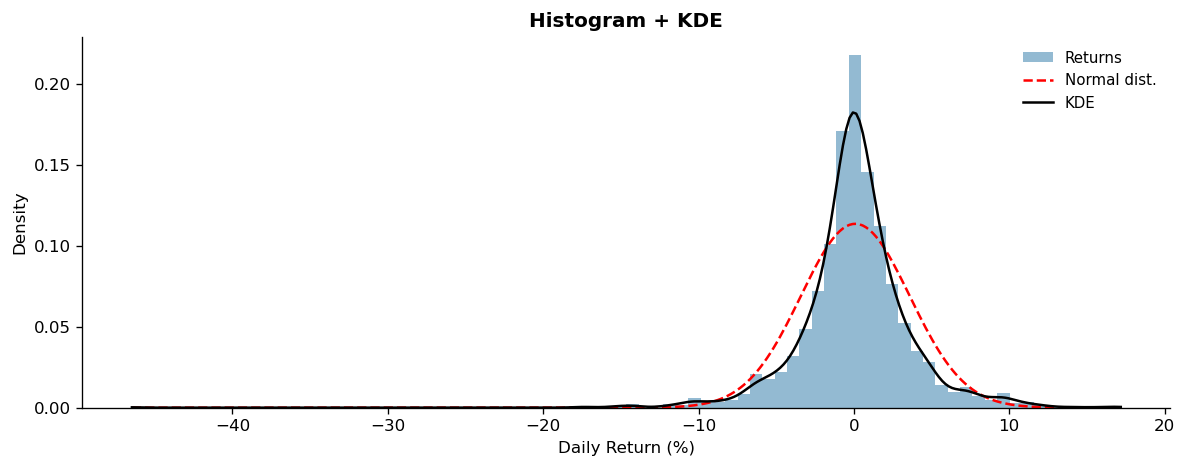

In [20]:
fig, ax = plt.subplots(figsize=(10, 4), facecolor="none")
ax.set_facecolor("none")
ax.hist(_r*100, bins=80, density=True, alpha=0.6,
        color="#4C8DB5", label="Returns")
_x = np.linspace(_r.min()*100, _r.max()*100, 300)
ax.plot(_x, norm.pdf(_x, _r.mean()*100, _r.std()*100),
        "r--", lw=1.5, label="Normal dist.")
ax.plot(_x, gaussian_kde(_r*100)(_x), "k-", lw=1.5, label="KDE")
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Density")
ax.set_title("Histogram + KDE", fontweight="bold")
ax.legend(fontsize=9, framealpha=0)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_returns.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

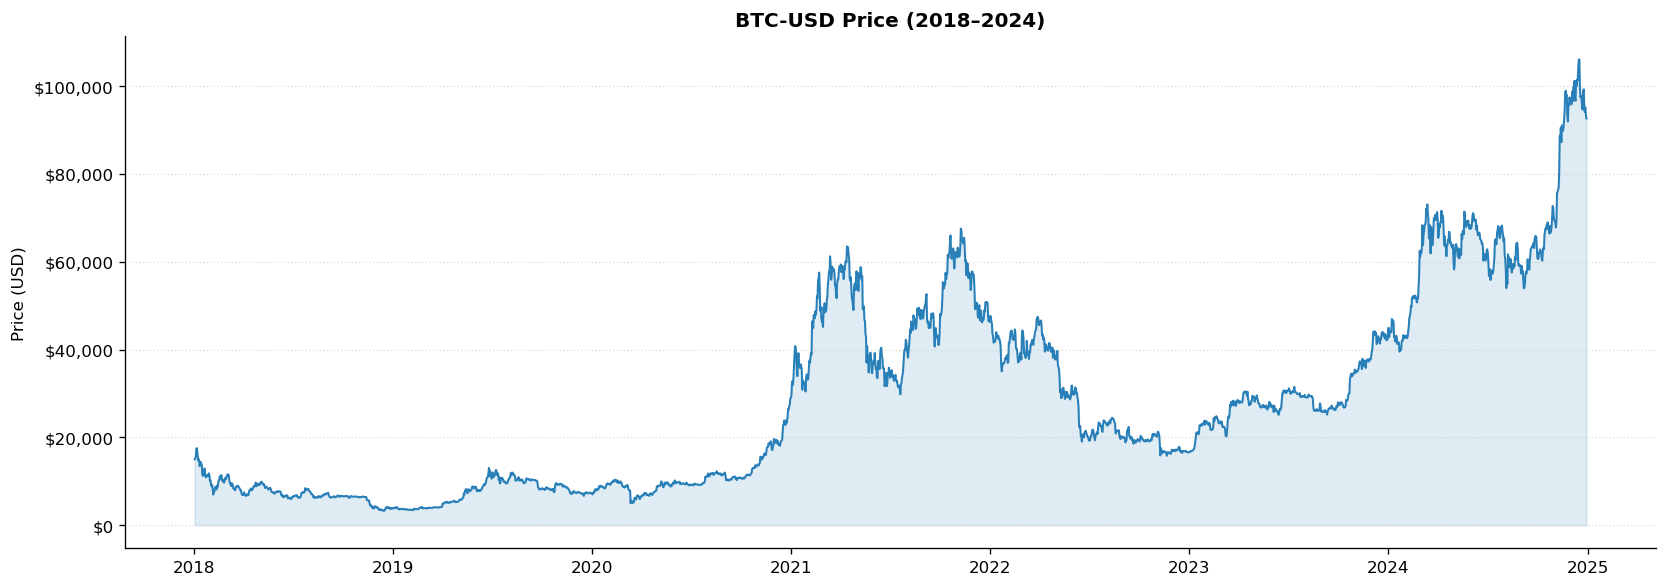

In [21]:
# ── 01 BTC Price ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor="none")
ax.set_facecolor("none")
ax.fill_between(df_btc.index, df_btc["Close"], color="#2980b9", alpha=0.15)
ax.plot(df_btc.index, df_btc["Close"], color="#2980b9", lw=1.2)
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:,.0f}"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("BTC-USD Price (2018–2024)", fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/eda_price.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

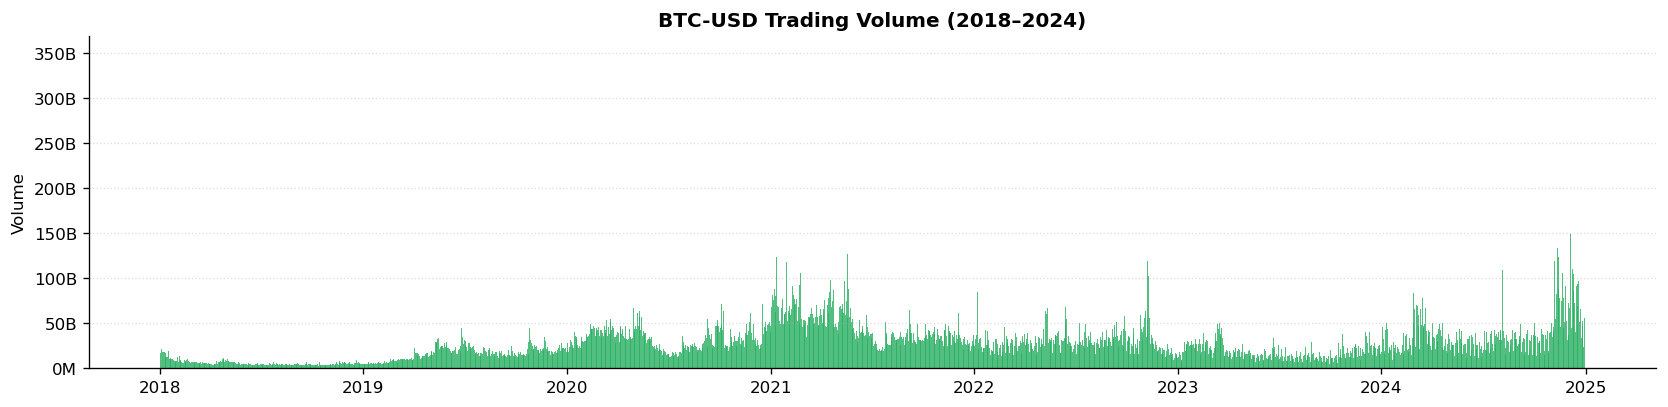

In [22]:
# ── 02 Volume ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3.5), facecolor="none")
ax.set_facecolor("none")
ax.bar(df_btc.index, df_btc["Volume"], color="#27ae60", alpha=0.8, width=1.2)
ax.set_ylabel("Volume")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x,_: f"{x/1e9:.0f}B" if x >= 1e9 else f"{x/1e6:.0f}M"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("BTC-USD Trading Volume (2018–2024)", fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/eda_volume.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

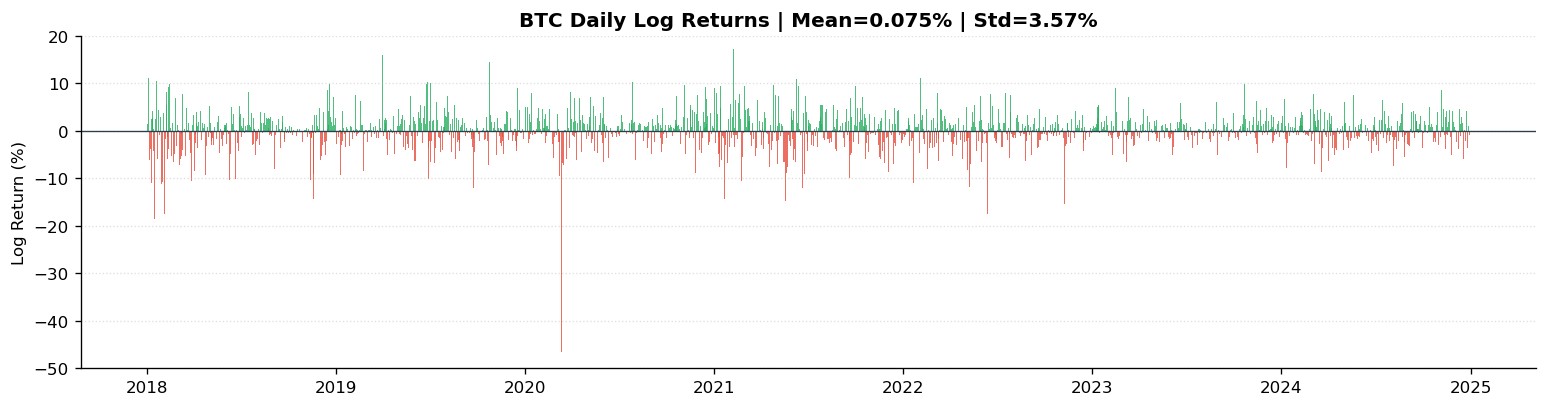

In [23]:
_ret = df_btc["LogReturn"].dropna()

fig, ax = plt.subplots(figsize=(13, 3.5), facecolor="none")
ax.set_facecolor("none")
ax.bar(_ret.index, _ret.clip(lower=0)*100, color="#27ae60", alpha=0.8, width=1.2)
ax.bar(_ret.index, _ret.clip(upper=0)*100, color="#e74c3c", alpha=0.8, width=1.2)
ax.axhline(0, color="#2c3e50", lw=0.8)
ax.set_ylim(-50, 20)
ax.set_ylabel("Log Return (%)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title(f"BTC Daily Log Returns | Mean={_ret.mean()*100:.3f}% | Std={_ret.std()*100:.2f}%",
             fontsize=12, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/eda_daily_returns.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

In [24]:
print(f"LogReturn min: {df_btc['LogReturn'].min()*100:.2f}%")
print(f"LogReturn max: {df_btc['LogReturn'].max()*100:.2f}%")
print(f"Worst day: {df_btc['LogReturn'].idxmin().date()}")

_r = df_btc["LogReturn"].dropna() * 100
print(f"Days |ret|>5%: {(_r.abs() > 5).sum()} ({(_r.abs() > 5).mean():.1%})")

LogReturn min: -46.47%
LogReturn max: 17.18%
Worst day: 2020-03-12
Days |ret|>5%: 312 (12.2%)


In [25]:
print(df_btc.loc["2020-03-12", "LogReturn"] * 100)

-46.4730175339773


In [26]:
print(df_btc.loc["2020-03-12", "Close"])   # sollte tiefer als Vortag sein
print(df_btc.loc["2020-03-11", "Close"])   # Vortag

4970.7880859375
7911.43017578125


In [27]:
print(df_btc["LogReturn"].min())
print(df_btc["LogReturn"].idxmin())

-0.46473017533977296
2020-03-12 00:00:00


In [28]:
print(df_btc["LogReturn"].nsmallest(10))

Date
2020-03-12   -0.464730
2018-01-16   -0.184582
2022-06-13   -0.174053
2018-02-05   -0.173982
2022-11-09   -0.154890
2019-06-27   -0.151820
2021-05-19   -0.148107
2018-11-19   -0.143561
2021-05-12   -0.142967
2021-01-21   -0.142528
Name: LogReturn, dtype: float64


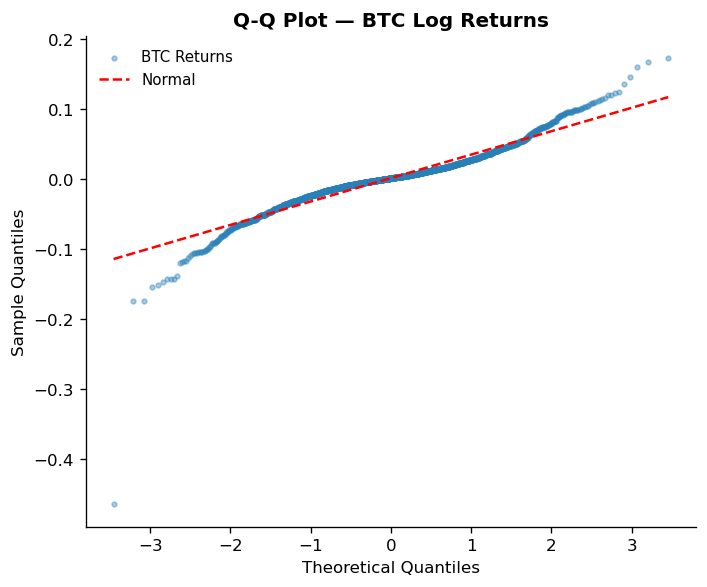

In [29]:
from scipy.stats import probplot
# ── 04 Q-Q Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5), facecolor="none")
ax.set_facecolor("none")
_res = probplot(df_clean["LogReturn"], dist="norm", plot=None)
ax.scatter(_res[0][0], _res[0][1], color="#2980b9",
           alpha=0.4, s=8, label="BTC Returns")
ax.plot(_res[0][0],
        _res[1][1] + _res[1][0] * _res[0][0],
        "r--", lw=1.5, label="Normal")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.set_title("Q-Q Plot — BTC Log Returns", fontweight="bold")
ax.legend(fontsize=9, framealpha=0)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_qq.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

In [30]:
_r = df_clean["LogReturn"] * 100
print(f"1%  quantile: {_r.quantile(0.01):+.2f}%")
print(f"5%  quantile: {_r.quantile(0.05):+.2f}%")
print(f"95% quantile: {_r.quantile(0.95):+.2f}%")
print(f"99% quantile: {_r.quantile(0.99):+.2f}%")

1%  quantile: -10.26%
5%  quantile: -5.34%
95% quantile: +5.40%
99% quantile: +9.80%


In [31]:
# ── Fat Tail Analysis ─────────────────────────────────────────
from scipy.stats import norm

_r   = df_clean["LogReturn"]
_std = _r.std()
_mu  = _r.mean()

# Wie viele Tage fallen unter -2 Std (normal: 2.28%)
_normal_pred = norm.cdf(-2) * 100
_actual      = (_r < (_mu - 2*_std)).mean() * 100
_excess      = ((_actual/_normal_pred)-1)*100

print(f"Days below -2std (normal): {_normal_pred:.2f}%")
print(f"Days below -2std (actual): {_actual:.2f}%")
print(f"Fat tail excess:           {_excess:.1f}% more extreme")

# Gleiches für -3std
_normal_pred3 = norm.cdf(-3) * 100
_actual3      = (_r < (_mu - 3*_std)).mean() * 100
_excess3      = ((_actual3/_normal_pred3)-1)*100

print(f"\nDays below -3std (normal): {_normal_pred3:.2f}%")
print(f"Days below -3std (actual): {_actual3:.2f}%")
print(f"Fat tail excess:           {_excess3:.1f}% more extreme")

Days below -2std (normal): 2.28%
Days below -2std (actual): 2.54%
Fat tail excess:           11.5% more extreme

Days below -3std (normal): 0.13%
Days below -3std (actual): 0.91%
Fat tail excess:           575.6% more extreme


In [32]:
print(f"Total days: {len(_r)}")
print(f"Days below -3std: {(_r < (_mu - 3*_std)).sum()}")
print(f"Expected (normal): {_normal_pred3/100 * len(_r):.1f} days")
print(f"Actual:            {(_r < (_mu - 3*_std)).sum()} days")
print(f"Ratio:             {_actual3/_normal_pred3:.1f}x more frequent")

Total days: 2522
Days below -3std: 23
Expected (normal): 3.4 days
Actual:            23 days
Ratio:             6.8x more frequent


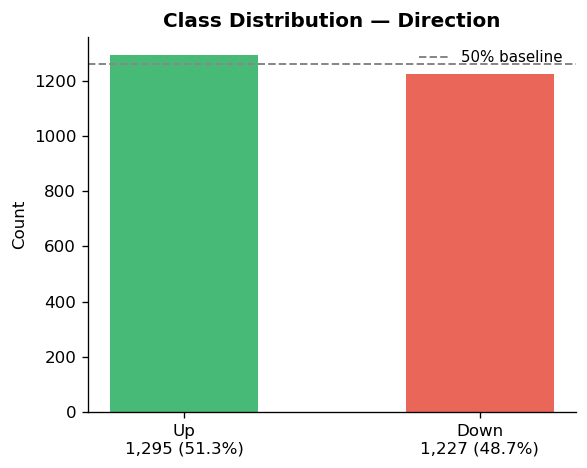

── Class Balance ─────────────────────────────────────
  Up days        : 1,295 (51.3%)
  Down days      : 1,227 (48.7%)
  Majority baseline: 0.5135
  AVG Up Return  : +2.3548%
  AVG Down Return: -2.2969%


In [33]:
# ── 06 Class Balance ──────────────────────────────────────────
_counts = [N_UP, N - N_UP]
_labels = [f"Up\n{N_UP:,} ({N_UP/N:.1%})",
           f"Down\n{N-N_UP:,} ({(N-N_UP)/N:.1%})"]
fig, ax = plt.subplots(figsize=(5, 4), facecolor="none")
ax.set_facecolor("none")
ax.bar(_labels, _counts, color=["#27ae60","#e74c3c"], alpha=0.85, width=0.5)
ax.axhline(N/2, color="#888888", linestyle="--", lw=1.2, label="50% baseline")
ax.set_ylabel("Count")
ax.set_title("Class Distribution — Direction", fontweight="bold")
ax.legend(fontsize=9, framealpha=0)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/eda_class_balance.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

# ── Class Balance ─────────────────────────────────────────────
_r   = df_clean["LogReturn"]
_up  = df_clean["Direction"].sum()
_dn  = len(df_clean) - _up

AVG_UP   = _r[df_clean["Direction"] == 1].mean() * 100
AVG_DOWN = _r[df_clean["Direction"] == 0].mean() * 100

print("── Class Balance ─────────────────────────────────────")
print(f"  Up days        : {_up:,} ({_up/len(df_clean):.1%})")
print(f"  Down days      : {_dn:,} ({_dn/len(df_clean):.1%})")
print(f"  Majority baseline: {max(_up,_dn)/len(df_clean):.4f}")
print(f"  AVG Up Return  : {AVG_UP:+.4f}%")
print(f"  AVG Down Return: {AVG_DOWN:+.4f}%")

In [34]:
from statsmodels.tsa.stattools import kpss

def _adf(_s):
    r = adfuller(_s.dropna(), autolag="AIC")
    return r[0], r[1]

def _kpss(_s):
    r = kpss(_s.dropna(), regression="c", nlags="auto")
    return r[0], r[1]

_price = df_btc["Close"].dropna()
_ret   = df_btc["LogReturn"].dropna()

print(f"{'Series':<15} {'ADF stat':>10} {'ADF p':>8} "
      f"{'KPSS stat':>10} {'KPSS p':>8} {'Result':>16}")
print("-" * 72)

for _name, _s in [("BTC Price", _price), ("BTC Returns", _ret)]:
    _a_s, _a_p = _adf(_s)
    _k_s, _k_p = _kpss(_s)
    _stat = "Stationary" if _a_p < 0.05 and _k_p > 0.05 else "Non-Stationary"
    print(f"{_name:<15} {_a_s:>10.4f} {_a_p:>8.4f} "
          f"{_k_s:>10.4f} {_k_p:>8.4f} {_stat:>16}")

_lb = acorr_ljungbox(_ret, lags=[5, 10, 20], return_df=True)
print(f"\nLjung-Box: Lag5 p={_lb['lb_pvalue'].iloc[0]:.4f} | "
      f"Lag10 p={_lb['lb_pvalue'].iloc[1]:.4f} | "
      f"Lag20 p={_lb['lb_pvalue'].iloc[2]:.4f}")

Series            ADF stat    ADF p  KPSS stat   KPSS p           Result
------------------------------------------------------------------------


C:\Users\aelawady\AppData\Local\Temp\ipykernel_34396\4205504031.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  r = kpss(_s.dropna(), regression="c", nlags="auto")


BTC Price          -0.3467   0.9186     4.9175   0.0100   Non-Stationary
BTC Returns       -34.9058   0.0000     0.1834   0.1000       Stationary

Ljung-Box: Lag5 p=0.0158 | Lag10 p=0.0370 | Lag20 p=0.2220


C:\Users\aelawady\AppData\Local\Temp\ipykernel_34396\4205504031.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(_s.dropna(), regression="c", nlags="auto")


In [35]:
# ── Log Returns & Target ──────────────────────────────────────
_r = df_btc["LogReturn"].dropna()
print(f"Log Returns : ln(P_t / P_{{t-1}}) | "
      f"Range: {_r.min()*100:+.2f}% → {_r.max()*100:+.2f}%")
print(f"Direction   : 1=Up ({df_btc['Direction'].mean():.1%})  "
      f"0=Down ({1-df_btc['Direction'].mean():.1%})")
print(f"dropna() : {len(df_btc):,} → {len(df_clean):,} rows "
      f"({len(df_btc)-len(df_clean)} rows — rolling windows & lags)")

# ── Fear & Greed ──────────────────────────────────────────────
_fg_nan_before = fg["FG_sentiment"].isna().sum()
print(f"\nF&G ffill() : {_fg_nan_before} NaN filled "
      f"| Range: {fg['FG_sentiment'].min():.3f} → "
      f"{fg['FG_sentiment'].max():.3f}")

# ── VADER ─────────────────────────────────────────────────────
_news_raw = pd.read_csv(VADER_CSV_IN)
_n_raw    = len(_news_raw)
_news_raw["Date"] = pd.to_datetime(_news_raw["Date"],
                                    errors="coerce").dt.normalize()
_n_invalid = _news_raw["Date"].isna().sum()
_n_empty   = (_news_raw["Short Description"].astype(str)
               .str.strip() == "").sum()
print(f"\nVADER raw headlines  : {_n_raw:,}")
print(f"  Invalid dates removed : {_n_invalid}")
print(f"  Empty headlines removed: {_n_empty}")
print(f"  Clean headlines used  : "
      f"{_n_raw - _n_invalid - _n_empty:,}")
print(f"  Daily aggregates      : {len(daily_vader):,} days")

Log Returns : ln(P_t / P_{t-1}) | Range: -46.47% → +17.18%
Direction   : 1=Up (51.4%)  0=Down (48.6%)
dropna() : 2,555 → 2,522 rows (33 rows — rolling windows & lags)

F&G ffill() : 0 NaN filled | Range: -0.900 → 0.900

VADER raw headlines  : 11,295
  Invalid dates removed : 0
  Empty headlines removed: 0
  Clean headlines used  : 11,295
  Daily aggregates      : 887 days


In [36]:
PARAMS_JSON = "outputs/best_params.json"

if os.path.exists(PARAMS_JSON):
    with open(PARAMS_JSON) as f:
        best_params = json.load(f)
else:
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV)

    def _cv(model_fn, params):
        sc = []
        for tr, va in tscv.split(X_tech_tr_sc):
            m = model_fn(**params)
            m.fit(X_tech_tr_sc[tr], y_tr[tr])
            sc.append(accuracy_score(y_tr[va],
                      m.predict(X_tech_tr_sc[va])))
        return np.mean(sc)

    def _run(name, obj):
        print(f"Optimizing {name}...")
        s = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=SEED))
        s.optimize(obj, n_trials=N_TRIALS, show_progress_bar=False)
        print(f"  Best CV Acc: {s.best_value:.4f}")
        return s

    def rf_obj(t):
        return _cv(RandomForestClassifier, {
            "n_estimators":     t.suggest_int("n_estimators", 200, 1500),
            "max_depth":        t.suggest_int("max_depth", 3, 10),
            "min_samples_leaf": t.suggest_int("min_samples_leaf", 5, 30),
            "max_features":     t.suggest_categorical("max_features",
                                                       ["sqrt", "log2"]),
            "random_state":SEED, "n_jobs":-1})

    def xgb_obj(t):
        return _cv(xgb.XGBClassifier, {
            "n_estimators":     t.suggest_int("n_estimators", 100, 1000),
            "max_depth":        t.suggest_int("max_depth", 2, 6),
            "learning_rate":    t.suggest_float("learning_rate",
                                                 0.005, 0.1, log=True),
            "subsample":        t.suggest_float("subsample", 0.5, 0.8),
            "colsample_bytree": t.suggest_float("colsample_bytree", 0.5, 0.8),
            "gamma":            t.suggest_float("gamma", 0.5, 5),
            "reg_alpha":        t.suggest_float("reg_alpha", 0.1, 10, log=True),
            "reg_lambda":       t.suggest_float("reg_lambda", 0.1, 10, log=True),
            "random_state":SEED, "eval_metric":"logloss", "verbosity":0})

    def lgb_obj(t):
        max_depth  = t.suggest_int("max_depth", 2, 6)
        max_leaves = min(2**max_depth, 63)
        min_leaves = min(4, max_leaves)
        return _cv(lgb.LGBMClassifier, {
            "n_estimators":      t.suggest_int("n_estimators", 100, 1000),
            "num_leaves":        t.suggest_int("num_leaves", min_leaves, max_leaves),
            "max_depth":         max_depth,
            "learning_rate":     t.suggest_float("learning_rate",
                                                  0.005, 0.1, log=True),
            "subsample":         t.suggest_float("subsample", 0.5, 0.8),
            "colsample_bytree":  t.suggest_float("colsample_bytree", 0.5, 0.8),
            "min_child_samples": t.suggest_int("min_child_samples", 20, 100),
            "reg_alpha":         t.suggest_float("reg_alpha", 0.1, 10, log=True),
            "reg_lambda":        t.suggest_float("reg_lambda", 0.1, 10, log=True),
            "random_state":SEED, "verbose":-1})

    rf_s  = _run("RF",  rf_obj)
    xgb_s = _run("XGB", xgb_obj)
    lgb_s = _run("LGB", lgb_obj)

    best_params = {
        "RF":  {**rf_s.best_params,  "random_state":SEED, "n_jobs":-1},
        "XGB": {**xgb_s.best_params, "random_state":SEED,
                "eval_metric":"logloss", "verbosity":0},
        "LGB": {**lgb_s.best_params, "random_state":SEED, "verbose":-1},
    }
    with open(PARAMS_JSON, "w") as f:
        json.dump(best_params, f, indent=2)

_skip = {"random_state","verbose","n_jobs","eval_metric","verbosity"}
for m, p in best_params.items():
    print(f"{m}: { {k:v for k,v in p.items() if k not in _skip} }")

RF: {'n_estimators': 356, 'max_depth': 8, 'min_samples_leaf': 19, 'max_features': 'sqrt'}
XGB: {'n_estimators': 347, 'max_depth': 3, 'learning_rate': 0.08212056072736397, 'subsample': 0.6066021130363833, 'colsample_bytree': 0.5172432011622204, 'gamma': 4.739826606530733, 'reg_alpha': 6.599127973372474, 'reg_lambda': 7.921587169314106}
LGB: {'max_depth': 5, 'n_estimators': 290, 'num_leaves': 24, 'learning_rate': 0.015901953990975288, 'subsample': 0.5733941271990494, 'colsample_bytree': 0.6887178552328633, 'min_child_samples': 84, 'reg_alpha': 3.233479485009171, 'reg_lambda': 7.281553948859293}


In [37]:
def _train(ModelClass, params, X_tr, y_tr, X_ts, y_ts):
    m     = ModelClass(**params)
    m.fit(X_tr, y_tr)
    pred  = m.predict(X_ts)
    proba = m.predict_proba(X_ts)[:,1]
    return (m, pred, proba,
            accuracy_score(y_ts, pred),
            precision_score(y_ts, pred, zero_division=0),
            recall_score(y_ts, pred, zero_division=0),
            f1_score(y_ts, pred, zero_division=0),
            roc_auc_score(y_ts, proba))

# ── Random Forest ─────────────────────────────────────────────
(rf,  rf_pred,  rf_proba,
 RF_ACC,  RF_PREC,  RF_REC,  RF_F1,  RF_AUC)  = _train(
    RandomForestClassifier, best_params["RF"],
    X_tech_tr_sc, y_tr, X_tech_ts_sc, y_ts_main)

(rf_s, rfs_pred, rfs_proba,
 RF_S_ACC, RF_S_PREC, RF_S_REC, RF_S_F1, RF_S_AUC) = _train(
    RandomForestClassifier, best_params["RF"],
    X_fg_tr_sc, y_tr, X_fg_ts_sc, y_ts_main)

# ── XGBoost ───────────────────────────────────────────────────
(xgb_m, xgb_pred, xgb_proba,
 XGB_ACC,  XGB_PREC,  XGB_REC,  XGB_F1,  XGB_AUC)  = _train(
    xgb.XGBClassifier, best_params["XGB"],
    X_tech_tr_sc, y_tr, X_tech_ts_sc, y_ts_main)

(xgb_s, xgbs_pred, xgbs_proba,
 XGB_S_ACC, XGB_S_PREC, XGB_S_REC, XGB_S_F1, XGB_S_AUC) = _train(
    xgb.XGBClassifier, best_params["XGB"],
    X_fg_tr_sc, y_tr, X_fg_ts_sc, y_ts_main)

# ── LightGBM ──────────────────────────────────────────────────
(lgb_m, lgb_pred, lgb_proba,
 LGB_ACC,  LGB_PREC,  LGB_REC,  LGB_F1,  LGB_AUC)  = _train(
    lgb.LGBMClassifier, best_params["LGB"],
    X_tech_tr_sc, y_tr, X_tech_ts_sc, y_ts_main)

(lgb_s, lgbs_pred, lgbs_proba,
 LGB_S_ACC, LGB_S_PREC, LGB_S_REC, LGB_S_F1, LGB_S_AUC) = _train(
    lgb.LGBMClassifier, best_params["LGB"],
    X_fg_tr_sc, y_tr, X_fg_ts_sc, y_ts_main)

# ── Voting Ensemble ───────────────────────────────────────────
ens = VotingClassifier([("rf",rf),("xgb",xgb_m),("lgb",lgb_m)],
                        voting="soft", weights=[1, 1, 2], n_jobs=-1)
ens.fit(X_tech_tr_sc, y_tr)
ens_pred  = ens.predict(X_tech_ts_sc)
ens_proba = ens.predict_proba(X_tech_ts_sc)[:,1]
ENS_ACC   = accuracy_score(y_ts_main,  ens_pred)
ENS_PREC  = precision_score(y_ts_main, ens_pred, zero_division=0)
ENS_REC   = recall_score(y_ts_main,   ens_pred, zero_division=0)
ENS_F1    = f1_score(y_ts_main,       ens_pred, zero_division=0)
ENS_AUC   = roc_auc_score(y_ts_main,  ens_proba)

ens_s = VotingClassifier([("rf",rf_s),("xgb",xgb_s),("lgb",lgb_s)],
                          voting="soft", weights=[1, 1, 2], n_jobs=-1)
ens_s.fit(X_fg_tr_sc, y_tr)
enss_pred  = ens_s.predict(X_fg_ts_sc)
enss_proba = ens_s.predict_proba(X_fg_ts_sc)[:,1]
ENS_S_ACC  = accuracy_score(y_ts_main,  enss_pred)
ENS_S_PREC = precision_score(y_ts_main, enss_pred, zero_division=0)
ENS_S_REC  = recall_score(y_ts_main,   enss_pred, zero_division=0)
ENS_S_F1   = f1_score(y_ts_main,       enss_pred, zero_division=0)
ENS_S_AUC  = roc_auc_score(y_ts_main,  enss_proba)

# ── Precision & Recall Summary ────────────────────────────────
print(f"\n{'Model':<18} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print("─" * 62)
for _n, _acc, _prec, _rec, _f1, _auc in [
    ("RF   (Tech)",  RF_ACC,    RF_PREC,    RF_REC,    RF_F1,    RF_AUC),
    ("RF   (+F&G)",  RF_S_ACC,  RF_S_PREC,  RF_S_REC,  RF_S_F1,  RF_S_AUC),
    ("XGB  (Tech)",  XGB_ACC,   XGB_PREC,   XGB_REC,   XGB_F1,   XGB_AUC),
    ("XGB  (+F&G)",  XGB_S_ACC, XGB_S_PREC, XGB_S_REC, XGB_S_F1, XGB_S_AUC),
    ("LGB  (Tech)",  LGB_ACC,   LGB_PREC,   LGB_REC,   LGB_F1,   LGB_AUC),
    ("LGB  (+F&G)",  LGB_S_ACC, LGB_S_PREC, LGB_S_REC, LGB_S_F1, LGB_S_AUC),
    ("ENS  (Tech)",  ENS_ACC,   ENS_PREC,   ENS_REC,   ENS_F1,   ENS_AUC),
    ("ENS  (+F&G)",  ENS_S_ACC, ENS_S_PREC, ENS_S_REC, ENS_S_F1, ENS_S_AUC),
]:
    print(f"{_n:<18} {_acc:>8.4f} {_prec:>8.4f} {_rec:>8.4f} "
          f"{_f1:>8.4f} {_auc:>8.4f}")


Model                   Acc     Prec      Rec       F1      AUC
──────────────────────────────────────────────────────────────
RF   (Tech)          0.5327   0.5650   0.4313   0.4892   0.5291
RF   (+F&G)          0.5505   0.5879   0.4466   0.5076   0.5513
XGB  (Tech)          0.5446   0.5630   0.5458   0.5543   0.5500
XGB  (+F&G)          0.5287   0.5414   0.5992   0.5688   0.5395
LGB  (Tech)          0.5248   0.5611   0.3855   0.4570   0.5298
LGB  (+F&G)          0.5386   0.5759   0.4198   0.4857   0.5363
ENS  (Tech)          0.5327   0.5714   0.3969   0.4685   0.5390
ENS  (+F&G)          0.5426   0.5838   0.4122   0.4832   0.5427


Pair                           n12   n21        p   Sig
────────────────────────────────────────────────────
RF   vs XGB  (Tech)             42    96   0.0000    * 
RF   vs LGB  (Tech)             58    38   0.0525      
RF   vs ENS  (Tech)             44    26   0.0422    * 
XGB  vs LGB  (Tech)            115    41   0.0000    * 
XGB  vs ENS  (Tech)            102    30   0.0000    * 
LGB  vs ENS  (Tech)             14    16   0.8551      
RF   vs RF   (+F&G)             36    35   1.0000      
XGB  vs XGB  (+F&G)             26    62   0.0002    * 
LGB  vs LGB  (+F&G)             20    31   0.1614      
ENS  vs ENS  (+F&G)             22    25   0.7705      


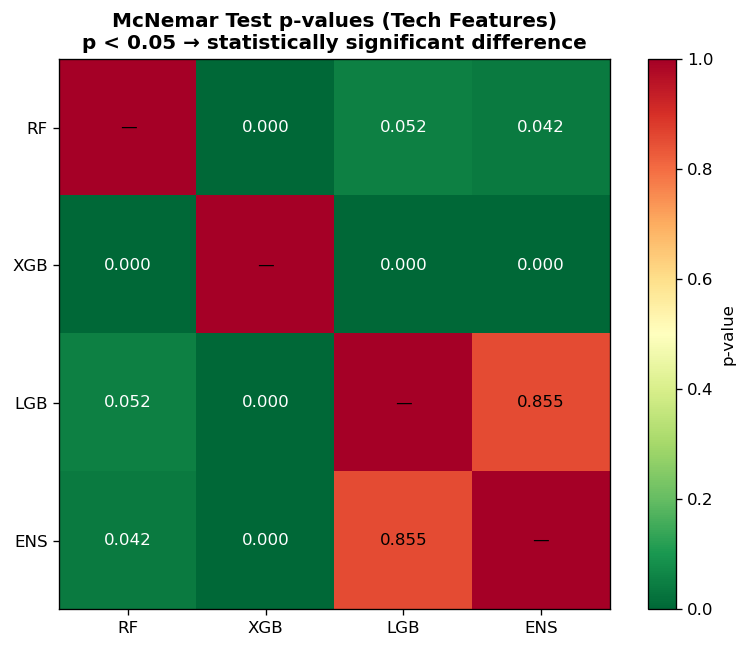

In [38]:
from scipy.stats import binom, norm

def _mcnemar(p1, p2, y):
    p1, p2, y = np.array(p1), np.array(p2), np.array(y)
    b = int(np.sum((p1==1)&(p2==0)))
    c = int(np.sum((p1==0)&(p2==1)))
    n = b + c
    if n == 0:
        return b, c, 1.0
    if n < 20:
        T = min(b, c)
        p = float(2 * binom.cdf(T, n, 0.5))
    else:
        z = (abs(b-c) - 1) / np.sqrt(b+c)
        p = float(2 * (1 - norm.cdf(z)))
    return b, c, round(min(p, 1.0), 4)

_pairs = [
    ("RF   vs XGB  (Tech)", rf_pred,   xgb_pred,  y_ts_main),
    ("RF   vs LGB  (Tech)", rf_pred,   lgb_pred,  y_ts_main),
    ("RF   vs ENS  (Tech)", rf_pred,   ens_pred,  y_ts_main),
    ("XGB  vs LGB  (Tech)", xgb_pred,  lgb_pred,  y_ts_main),
    ("XGB  vs ENS  (Tech)", xgb_pred,  ens_pred,  y_ts_main),
    ("LGB  vs ENS  (Tech)", lgb_pred,  ens_pred,  y_ts_main),
    ("RF   vs RF   (+F&G)", rf_pred,   rfs_pred,  y_ts_main),
    ("XGB  vs XGB  (+F&G)", xgb_pred,  xgbs_pred, y_ts_main),
    ("LGB  vs LGB  (+F&G)", lgb_pred,  lgbs_pred, y_ts_main),
    ("ENS  vs ENS  (+F&G)", ens_pred,  enss_pred, y_ts_main),
]

print(f"{'Pair':<28} {'n12':>5} {'n21':>5} {'p':>8} {'Sig':>5}")
print("─" * 52)
for _name, _p1, _p2, _y in _pairs:
    b, c, p = _mcnemar(_p1, _p2, _y)
    _sig = "* " if p < 0.05 else ""
    print(f"{_name:<28} {b:>5} {c:>5} {p:>8.4f} {_sig:>5}")

# ── Heatmap (Tech only) ───────────────────────────────────────
_models = ["RF", "XGB", "LGB", "ENS"]
_preds  = [rf_pred, xgb_pred, lgb_pred, ens_pred]
_n      = len(_models)
_pmat   = np.ones((_n, _n))

for i in range(_n):
    for j in range(_n):
        if i != j:
            _, _, p = _mcnemar(_preds[i], _preds[j], y_ts_main)
            _pmat[i, j] = p

fig, ax = plt.subplots(figsize=(7, 5.5), facecolor="none")
ax.set_facecolor("none")
_im = ax.imshow(_pmat, cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(_im, ax=ax, label="p-value")
ax.set_xticks(range(_n)); ax.set_xticklabels(_models)
ax.set_yticks(range(_n)); ax.set_yticklabels(_models)
for i in range(_n):
    for j in range(_n):
        _txt = "—" if i==j else f"{_pmat[i,j]:.3f}"
        _col = "white" if _pmat[i,j] < 0.3 else "black"
        ax.text(j, i, _txt, ha="center", va="center",
                fontsize=10, color=_col)
ax.set_title("McNemar Test p-values (Tech Features)\n"
             "p < 0.05 → statistically significant difference",
             fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/mcnemar_heatmap.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

In [39]:
# ── Tech only (Overlap) ───────────────────────────────────────
(rf_ol_tech, rf_ol_tech_pred, rf_ol_tech_proba,
 RF_OL_TECH_ACC, RF_OL_TECH_PREC, RF_OL_TECH_REC,
 RF_OL_TECH_F1,  RF_OL_TECH_AUC) = _train(
    RandomForestClassifier, best_params["RF"],
    X_ol_tech_tr_sc, y_ol_tr, X_ol_tech_ts_sc, y_ol_ts)

(xgb_ol_tech, xgb_ol_tech_pred, xgb_ol_tech_proba,
 XGB_OL_TECH_ACC, XGB_OL_TECH_PREC, XGB_OL_TECH_REC,
 XGB_OL_TECH_F1,  XGB_OL_TECH_AUC) = _train(
    xgb.XGBClassifier, best_params["XGB"],
    X_ol_tech_tr_sc, y_ol_tr, X_ol_tech_ts_sc, y_ol_ts)

(lgb_ol_tech, lgb_ol_tech_pred, lgb_ol_tech_proba,
 LGB_OL_TECH_ACC, LGB_OL_TECH_PREC, LGB_OL_TECH_REC,
 LGB_OL_TECH_F1,  LGB_OL_TECH_AUC) = _train(
    lgb.LGBMClassifier, best_params["LGB"],
    X_ol_tech_tr_sc, y_ol_tr, X_ol_tech_ts_sc, y_ol_ts)

ens_ol_tech = VotingClassifier(
    [("rf", rf_ol_tech), ("xgb", xgb_ol_tech), ("lgb", lgb_ol_tech)],
    voting="soft", weights=[1, 1, 2], n_jobs=-1)
ens_ol_tech.fit(X_ol_tech_tr_sc, y_ol_tr)
ens_ol_tech_pred  = ens_ol_tech.predict(X_ol_tech_ts_sc)
ens_ol_tech_proba = ens_ol_tech.predict_proba(X_ol_tech_ts_sc)[:,1]
ENS_OL_TECH_ACC   = accuracy_score(y_ol_ts,  ens_ol_tech_pred)
ENS_OL_TECH_PREC  = precision_score(y_ol_ts, ens_ol_tech_pred, zero_division=0)
ENS_OL_TECH_REC   = recall_score(y_ol_ts,   ens_ol_tech_pred, zero_division=0)
ENS_OL_TECH_F1    = f1_score(y_ol_ts,       ens_ol_tech_pred, zero_division=0)
ENS_OL_TECH_AUC   = roc_auc_score(y_ol_ts,  ens_ol_tech_proba)

# ── Tech + VADER (Overlap) ────────────────────────────────────
(rf_ol, rf_ol_pred, rf_ol_proba,
 RF_OL_ACC, RF_OL_PREC, RF_OL_REC, RF_OL_F1, RF_OL_AUC) = _train(
    RandomForestClassifier, best_params["RF"],
    X_ol_tr_sc, y_ol_tr, X_ol_ts_sc, y_ol_ts)

(xgb_ol, xgb_ol_pred, xgb_ol_proba,
 XGB_OL_ACC, XGB_OL_PREC, XGB_OL_REC, XGB_OL_F1, XGB_OL_AUC) = _train(
    xgb.XGBClassifier, best_params["XGB"],
    X_ol_tr_sc, y_ol_tr, X_ol_ts_sc, y_ol_ts)

(lgb_ol, lgb_ol_pred, lgb_ol_proba,
 LGB_OL_ACC, LGB_OL_PREC, LGB_OL_REC, LGB_OL_F1, LGB_OL_AUC) = _train(
    lgb.LGBMClassifier, best_params["LGB"],
    X_ol_tr_sc, y_ol_tr, X_ol_ts_sc, y_ol_ts)

ens_ol = VotingClassifier(
    [("rf", rf_ol), ("xgb", xgb_ol), ("lgb", lgb_ol)],
    voting="soft", weights=[1, 1, 2], n_jobs=-1)
ens_ol.fit(X_ol_tr_sc, y_ol_tr)
ens_ol_pred  = ens_ol.predict(X_ol_ts_sc)
ens_ol_proba = ens_ol.predict_proba(X_ol_ts_sc)[:,1]
ENS_OL_ACC   = accuracy_score(y_ol_ts,  ens_ol_pred)
ENS_OL_PREC  = precision_score(y_ol_ts, ens_ol_pred, zero_division=0)
ENS_OL_REC   = recall_score(y_ol_ts,   ens_ol_pred, zero_division=0)
ENS_OL_F1    = f1_score(y_ol_ts,       ens_ol_pred, zero_division=0)
ENS_OL_AUC   = roc_auc_score(y_ol_ts,  ens_ol_proba)

# ── Results ───────────────────────────────────────────────────
print(f"{'Model':<22} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print("─" * 66)
for _n, _acc, _prec, _rec, _f1, _auc in [
    ("RF   (Tech)",   RF_OL_TECH_ACC,  RF_OL_TECH_PREC,  RF_OL_TECH_REC,  RF_OL_TECH_F1,  RF_OL_TECH_AUC),
    ("RF   (+VADER)", RF_OL_ACC,       RF_OL_PREC,       RF_OL_REC,       RF_OL_F1,       RF_OL_AUC),
    ("XGB  (Tech)",   XGB_OL_TECH_ACC, XGB_OL_TECH_PREC, XGB_OL_TECH_REC, XGB_OL_TECH_F1, XGB_OL_TECH_AUC),
    ("XGB  (+VADER)", XGB_OL_ACC,      XGB_OL_PREC,      XGB_OL_REC,      XGB_OL_F1,      XGB_OL_AUC),
    ("LGB  (Tech)",   LGB_OL_TECH_ACC, LGB_OL_TECH_PREC, LGB_OL_TECH_REC, LGB_OL_TECH_F1, LGB_OL_TECH_AUC),
    ("LGB  (+VADER)", LGB_OL_ACC,      LGB_OL_PREC,      LGB_OL_REC,      LGB_OL_F1,      LGB_OL_AUC),
    ("ENS  (Tech)",   ENS_OL_TECH_ACC, ENS_OL_TECH_PREC, ENS_OL_TECH_REC, ENS_OL_TECH_F1, ENS_OL_TECH_AUC),
    ("ENS  (+VADER)", ENS_OL_ACC,      ENS_OL_PREC,      ENS_OL_REC,      ENS_OL_F1,      ENS_OL_AUC),
]:
    print(f"{_n:<22} {_acc:>8.4f} {_prec:>8.4f} {_rec:>8.4f} "
          f"{_f1:>8.4f} {_auc:>8.4f}")

Model                       Acc     Prec      Rec       F1      AUC
──────────────────────────────────────────────────────────────────
RF   (Tech)              0.5393   0.6774   0.2258   0.3387   0.5943
RF   (+VADER)            0.5281   0.6452   0.2151   0.3226   0.6087
XGB  (Tech)              0.5449   0.6667   0.2581   0.3721   0.6017
XGB  (+VADER)            0.5393   0.6774   0.2258   0.3387   0.5923
LGB  (Tech)              0.5506   0.6444   0.3118   0.4203   0.5938
LGB  (+VADER)            0.5225   0.6000   0.2581   0.3609   0.5924
ENS  (Tech)              0.5225   0.6111   0.2366   0.3411   0.6040
ENS  (+VADER)            0.5281   0.6452   0.2151   0.3226   0.6091


In [40]:
LSTM_JSON = "outputs/lstm_best_params.json"

def make_seqs(X, y, w):
    return (np.array([X[i-w:i] for i in range(w, len(X))]),
            np.array(y[w:]))

def build_lstm(window, n_feat, units1, units2, dropout, lr):
    tf.random.set_seed(SEED)
    m = Sequential([
        KerasLSTM(units1, return_sequences=True,
                  input_shape=(window, n_feat)),
        BatchNormalization(), Dropout(dropout),
        KerasLSTM(units2),
        BatchNormalization(), Dropout(dropout),
        Dense(32, activation="relu"), Dropout(dropout/2),
        Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

if os.path.exists(LSTM_JSON):
    with open(LSTM_JSON) as f:
        lstm_best = json.load(f)
else:
    def lstm_obj(trial):
        window  = trial.suggest_categorical("window",[3,5,7,10,14,21])
        units1  = trial.suggest_categorical("units1",[64,128,256])
        units2  = trial.suggest_categorical("units2",[32,64,128])
        dropout = trial.suggest_float("dropout",0.1,0.4)
        lr      = trial.suggest_float("lr",1e-4,1e-2,log=True)
        batch   = trial.suggest_categorical("batch_size",[16,32,64])
        tscv3   = TimeSeriesSplit(n_splits=3)
        scores  = []
        for tr_idx, va_idx in tscv3.split(X_tech_tr_sc):
            if len(X_tech_tr_sc[tr_idx]) < window+10: return 0.5
            X_seq_tr, y_seq_tr = make_seqs(X_tech_tr_sc[tr_idx],
                                            y_tr[tr_idx], window)
            X_comb = np.concatenate([X_tech_tr_sc[tr_idx][-window:],
                                      X_tech_tr_sc[va_idx]])
            y_comb = np.concatenate([y_tr[tr_idx][-window:],y_tr[va_idx]])
            X_seq_va, y_seq_va = make_seqs(X_comb, y_comb, window)
            m = build_lstm(window, X_tech_tr_sc.shape[1],
                            units1, units2, dropout, lr)
            m.fit(X_seq_tr, y_seq_tr, epochs=30, batch_size=batch,
                  validation_data=(X_seq_va, y_seq_va),
                  callbacks=[EarlyStopping(patience=5,
                             restore_best_weights=True, verbose=0)],
                  verbose=0)
            proba = m.predict(X_seq_va, verbose=0).flatten()
            scores.append(accuracy_score(y_seq_va,
                          (proba > 0.5).astype(int)))
            del m; tf.keras.backend.clear_session()
        return np.mean(scores)

    print("Optimizing LSTM (20 trials)...")
    _ls = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=SEED))
    _ls.optimize(lstm_obj, n_trials=20, show_progress_bar=False)
    lstm_best = {**_ls.best_params, "cv_acc": _ls.best_value}
    with open(LSTM_JSON,"w") as f:
        json.dump(lstm_best, f, indent=2)
    print(f"Best Window: {lstm_best['window']} | CV Acc: {lstm_best['cv_acc']:.4f}")

WINDOW   = lstm_best["window"]
units1   = lstm_best["units1"]
units2   = lstm_best["units2"]
dropout  = lstm_best["dropout"]
lr       = lstm_best["lr"]
batch_sz = lstm_best["batch_size"]

print(f"LSTM params: window={WINDOW}, units={units1}/{units2}, "
      f"dropout={dropout:.2f}, lr={lr:.5f}, batch={batch_sz}")

X_tr_l,  y_tr_l  = make_seqs(X_tech_tr_sc, y_tr,      WINDOW)
X_ts_l,  y_ts_l  = make_seqs(X_tech_ts_sc, y_ts_main, WINDOW)
Xs_tr_l, _       = make_seqs(X_fg_tr_sc,   y_tr,      WINDOW)
Xs_ts_l, _       = make_seqs(X_fg_ts_sc,   y_ts_main, WINDOW)
test_dates_lstm   = test_dates[WINDOW:]
ret_ts_lstm       = ret_ts[WINDOW:]

cbs = [EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
       ReduceLROnPlateau(patience=7, factor=0.5, verbose=0)]

# ── LSTM (Technical) ──────────────────────────────────────────
print("Training LSTM (Tech)...")
lstm_tech = build_lstm(WINDOW, len(FEAT), units1, units2, dropout, lr)
lstm_tech.fit(X_tr_l, y_tr_l, epochs=120, batch_size=batch_sz,
              validation_split=0.15, callbacks=cbs, verbose=0)
lp        = lstm_tech.predict(X_ts_l, verbose=0).flatten()
lstm_pred = (lp > 0.5).astype(int)
LSTM_ACC  = accuracy_score(y_ts_l,  lstm_pred)
LSTM_PREC = precision_score(y_ts_l, lstm_pred, zero_division=0)
LSTM_REC  = recall_score(y_ts_l,   lstm_pred, zero_division=0)
LSTM_F1   = f1_score(y_ts_l,       lstm_pred, zero_division=0)
LSTM_AUC  = roc_auc_score(y_ts_l,  lp)
print(f"  LSTM (Tech): Acc={LSTM_ACC:.4f} F1={LSTM_F1:.4f} AUC={LSTM_AUC:.4f}")

# ── LSTM (Technical + F&G) ────────────────────────────────────
print("Training LSTM (+F&G)...")
lstm_fg = build_lstm(WINDOW, len(FEAT_FG), units1, units2, dropout, lr)
lstm_fg.fit(Xs_tr_l, y_tr_l, epochs=120, batch_size=batch_sz,
             validation_split=0.15, callbacks=cbs, verbose=0)
lsp        = lstm_fg.predict(Xs_ts_l, verbose=0).flatten()
lstms_pred = (lsp > 0.5).astype(int)
LSTM_S_ACC  = accuracy_score(y_ts_l,  lstms_pred)
LSTM_S_PREC = precision_score(y_ts_l, lstms_pred, zero_division=0)
LSTM_S_REC  = recall_score(y_ts_l,   lstms_pred, zero_division=0)
LSTM_S_F1   = f1_score(y_ts_l,       lstms_pred, zero_division=0)
LSTM_S_AUC  = roc_auc_score(y_ts_l,  lsp)
print(f"  LSTM (+F&G): Acc={LSTM_S_ACC:.4f} F1={LSTM_S_F1:.4f} AUC={LSTM_S_AUC:.4f}")

LSTM params: window=7, units=256/64, dropout=0.25, lr=0.00576, batch=32
Training LSTM (Tech)...
  LSTM (Tech): Acc=0.4739 F1=0.2294 AUC=0.5066
Training LSTM (+F&G)...
  LSTM (+F&G): Acc=0.4679 F1=0.2740 AUC=0.4969


In [41]:
# ── LSTM (Tech only — Overlap) ────────────────────────────────
X_ol_tech_tr_l, y_ol_tech_tr_l = make_seqs(X_ol_tech_tr_sc, y_ol_tr, WINDOW)
X_ol_tech_ts_l, y_ol_tech_ts_l = make_seqs(X_ol_tech_ts_sc, y_ol_ts, WINDOW)

print("Training LSTM (Tech — Overlap)...")
lstm_ol_tech = build_lstm(WINDOW, len(FEAT), units1, units2, dropout, lr)
lstm_ol_tech.fit(X_ol_tech_tr_l, y_ol_tech_tr_l, epochs=120,
                 batch_size=batch_sz, validation_split=0.15,
                 callbacks=cbs, verbose=0)

lp_ol_tech        = lstm_ol_tech.predict(X_ol_tech_ts_l, verbose=0).flatten()
lstm_ol_tech_pred = (lp_ol_tech > 0.5).astype(int)

LSTM_OL_TECH_ACC  = accuracy_score(y_ol_tech_ts_l,  lstm_ol_tech_pred)
LSTM_OL_TECH_PREC = precision_score(y_ol_tech_ts_l, lstm_ol_tech_pred, zero_division=0)
LSTM_OL_TECH_REC  = recall_score(y_ol_tech_ts_l,   lstm_ol_tech_pred, zero_division=0)
LSTM_OL_TECH_F1   = f1_score(y_ol_tech_ts_l,       lstm_ol_tech_pred, zero_division=0)
LSTM_OL_TECH_AUC  = roc_auc_score(y_ol_tech_ts_l,  lp_ol_tech)

# ── LSTM (Tech + VADER — Overlap) ─────────────────────────────
X_ol_tr_l, y_ol_tr_l = make_seqs(X_ol_tr_sc, y_ol_tr, WINDOW)
X_ol_ts_l, y_ol_ts_l = make_seqs(X_ol_ts_sc, y_ol_ts, WINDOW)
test_dates_ol_lstm    = test_dates_ol[WINDOW:]
ret_ts_ol_lstm        = ret_ts_ol[WINDOW:]

print("Training LSTM (+VADER)...")
lstm_ol = build_lstm(WINDOW, len(FEAT_VADER), units1, units2, dropout, lr)
lstm_ol.fit(X_ol_tr_l, y_ol_tr_l, epochs=120, batch_size=batch_sz,
            validation_split=0.15, callbacks=cbs, verbose=0)

lp_ol        = lstm_ol.predict(X_ol_ts_l, verbose=0).flatten()
lstm_ol_pred = (lp_ol > 0.5).astype(int)

LSTM_OL_ACC  = accuracy_score(y_ol_ts_l,  lstm_ol_pred)
LSTM_OL_PREC = precision_score(y_ol_ts_l, lstm_ol_pred, zero_division=0)
LSTM_OL_REC  = recall_score(y_ol_ts_l,   lstm_ol_pred, zero_division=0)
LSTM_OL_F1   = f1_score(y_ol_ts_l,       lstm_ol_pred, zero_division=0)
LSTM_OL_AUC  = roc_auc_score(y_ol_ts_l,  lp_ol)

# ── Results ───────────────────────────────────────────────────
print(f"\n{'Model':<22} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print("─" * 66)
for _n, _acc, _prec, _rec, _f1, _auc in [
    ("LSTM (Tech)",   LSTM_OL_TECH_ACC,  LSTM_OL_TECH_PREC,
                      LSTM_OL_TECH_REC,  LSTM_OL_TECH_F1,  LSTM_OL_TECH_AUC),
    ("LSTM (+VADER)", LSTM_OL_ACC,       LSTM_OL_PREC,
                      LSTM_OL_REC,       LSTM_OL_F1,       LSTM_OL_AUC),
]:
    print(f"{_n:<22} {_acc:>8.4f} {_prec:>8.4f} {_rec:>8.4f} "
          f"{_f1:>8.4f} {_auc:>8.4f}")

Training LSTM (Tech — Overlap)...
Training LSTM (+VADER)...

Model                       Acc     Prec      Rec       F1      AUC
──────────────────────────────────────────────────────────────────
LSTM (Tech)              0.5146   0.5652   0.2921   0.3852   0.5185
LSTM (+VADER)            0.4912   0.6667   0.0449   0.0842   0.5362


In [42]:
# ── LSTM Results Summary ──────────────────────────────────────
print(f"\n{'Model':<18} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'AUC':>8}")
print("─" * 58)
for _n, _acc, _prec, _rec, _f1, _auc in [
    ("LSTM (Tech)", LSTM_ACC,   LSTM_PREC,   LSTM_REC,   LSTM_F1,   LSTM_AUC),
    ("LSTM (+F&G)", LSTM_S_ACC, LSTM_S_PREC, LSTM_S_REC, LSTM_S_F1, LSTM_S_AUC),
]:
    print(f"{_n:<18} {_acc:>8.4f} {_prec:>8.4f} {_rec:>8.4f} "
          f"{_f1:>8.4f} {_auc:>8.4f}")


Model                   Acc     Prec      Rec       F1      AUC
──────────────────────────────────────────────────────────
LSTM (Tech)          0.4739   0.4815   0.1506   0.2294   0.5066
LSTM (+F&G)          0.4679   0.4717   0.1931   0.2740   0.4969


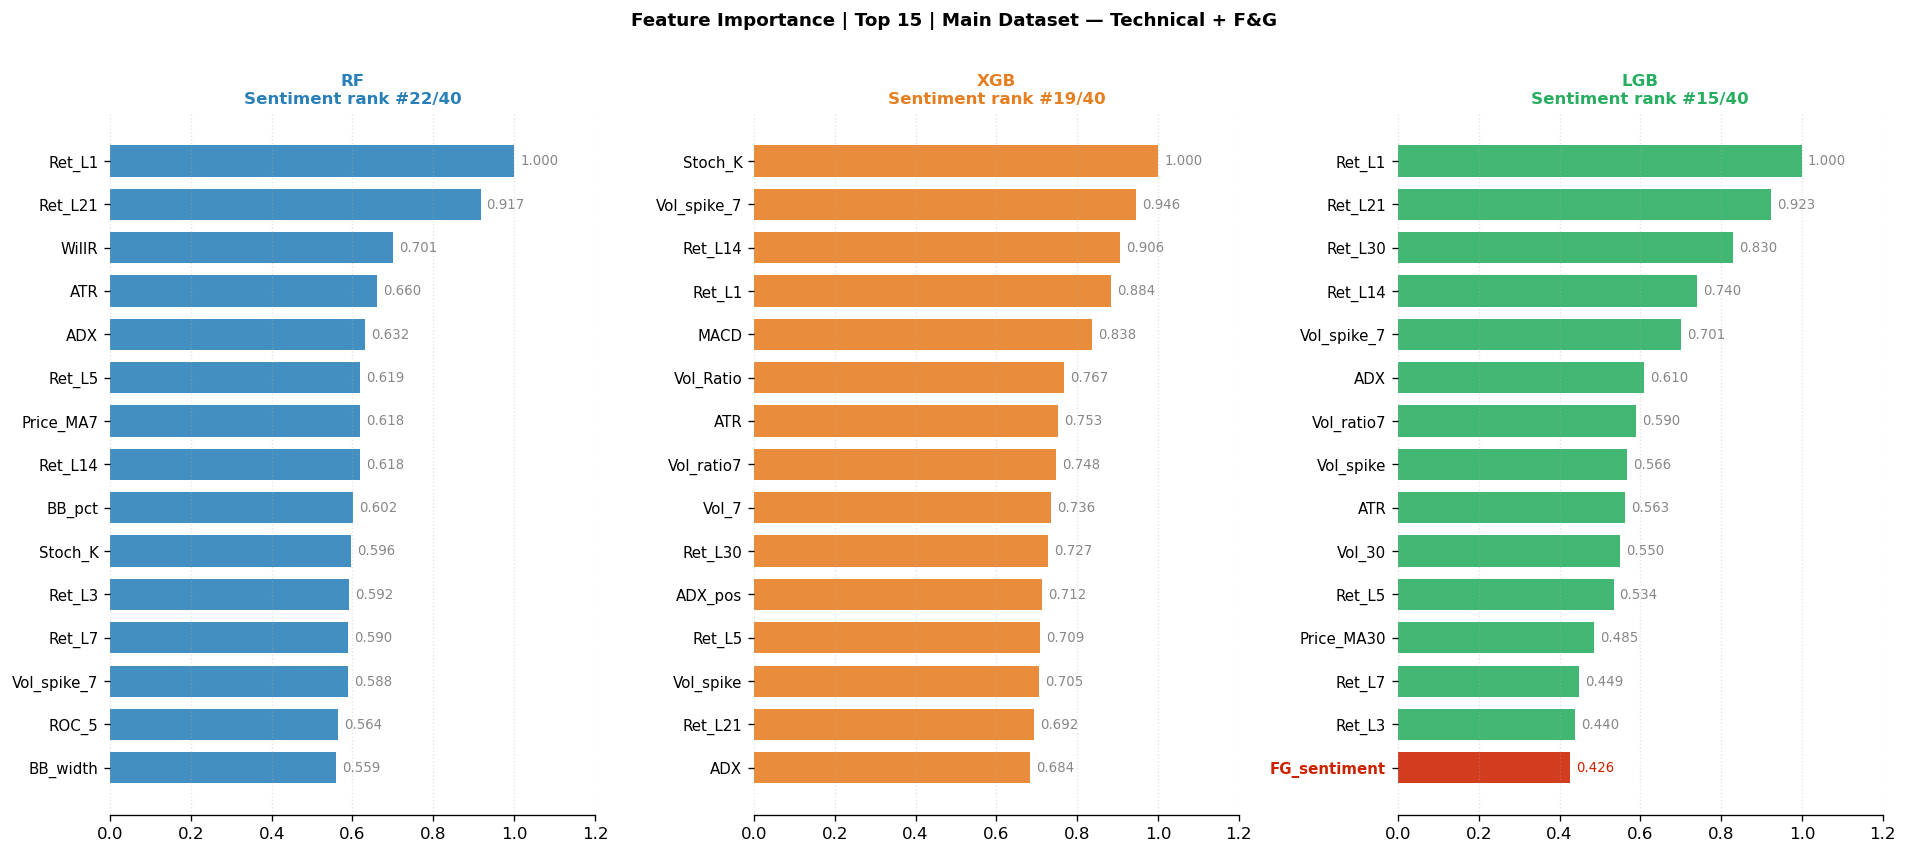

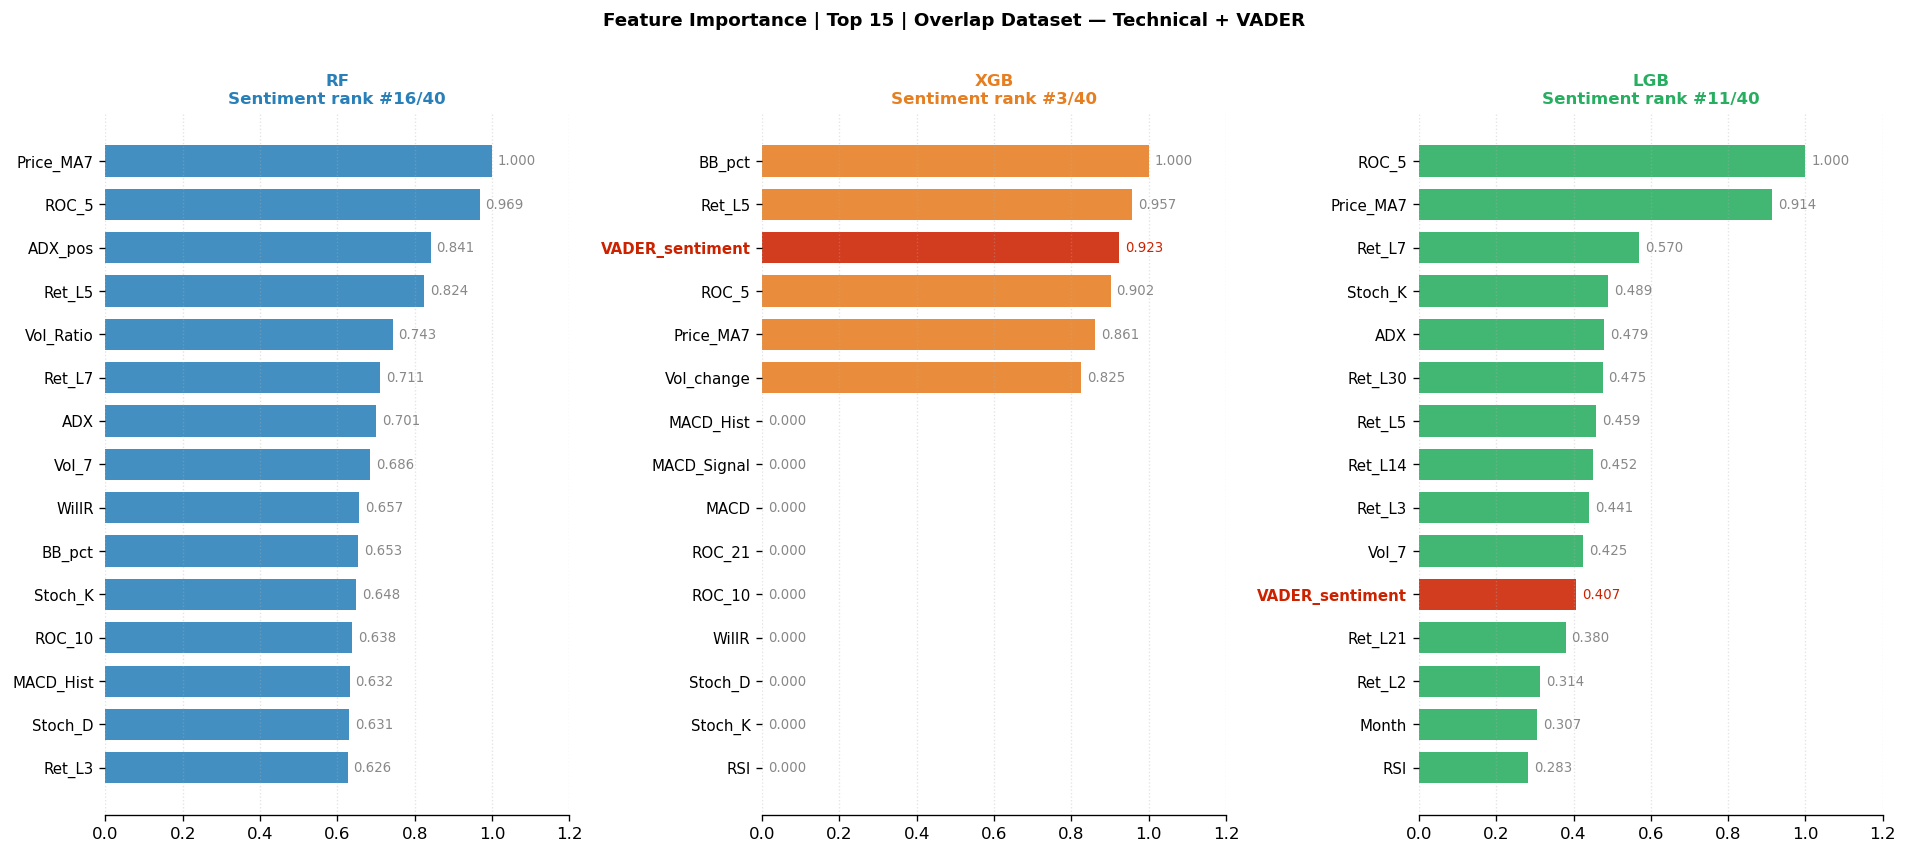

In [43]:
def _get_fi(model, feat_names, mname):
    if mname == "RF":
        _s = pd.Series(model.feature_importances_, index=feat_names)
    elif mname == "XGB":
        _booster = model.get_booster()
        _booster.feature_names = list(feat_names)
        _raw = _booster.get_score(importance_type="gain")
        _s   = pd.Series(0.0, index=feat_names)
        for k, v in _raw.items():
            if k in feat_names:
                _s[k] = v
    else:
        _s = pd.Series(
            model.booster_.feature_importance(importance_type="gain"),
            index=feat_names)
    return _s / _s.max() if _s.max() > 0 else _s

N_TOP  = 15
_SENT  = "#CC2200"
_BLUE  = "#2980b9"
_ORG   = "#e67e22"
_GRN   = "#27ae60"

for _title, _feat_names, _sent_col, _models_fi in [
    ("Main Dataset — Technical + F&G",
     FEAT_FG,
     "FG_sentiment",
     [("RF",  rf_s,  _BLUE),
      ("XGB", xgb_s, _ORG),
      ("LGB", lgb_s, _GRN)]),
    ("Overlap Dataset — Technical + VADER",
     FEAT_VADER,
     "VADER_sentiment",
     [("RF",  rf_ol,  _BLUE),
      ("XGB", xgb_ol, _ORG),
      ("LGB", lgb_ol, _GRN)]),
]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 7), facecolor="none")
    fig.suptitle(f"Feature Importance | Top {N_TOP} | {_title}",
                 fontsize=11, fontweight="bold", y=1.01)

    for ax, (mname, model, color) in zip(axes, _models_fi):
        ax.set_facecolor("none")
        fi   = _get_fi(model, _feat_names, mname)
        top  = fi.nlargest(N_TOP).sort_values(ascending=True)
        _bar_colors = [_SENT if f == _sent_col else color
                       for f in top.index]
        ax.barh(range(N_TOP), top.values, color=_bar_colors,
                alpha=0.88, height=0.72)
        for i, (v, f) in enumerate(zip(top.values, top.index)):
            ax.text(v+0.015, i, f"{v:.3f}", va="center",
                    fontsize=8,
                    color=_SENT if f == _sent_col else "#888888")
        ax.set_yticks(range(N_TOP))
        ax.set_yticklabels(top.index, fontsize=9)
        for tick, f in zip(ax.get_yticklabels(), top.index):
            if f == _sent_col:
                tick.set_color(_SENT)
                tick.set_fontweight("bold")
        _rank = int(fi.rank(ascending=False)[_sent_col])
        ax.set_title(f"{mname}\nSentiment rank #{_rank}/{len(_feat_names)}",
                     fontsize=10, fontweight="bold", color=color)
        ax.set_xlim(0, 1.2)
        ax.spines[["top","right","left"]].set_visible(False)
        ax.xaxis.grid(True, linestyle=":", alpha=0.35)

    plt.tight_layout()
    _fname = "main" if "F&G" in _title else "overlap"
    plt.savefig(f"outputs/feature_importance_{_fname}.png",
                dpi=150, bbox_inches="tight", transparent=True)
    plt.show(); plt.close()

In [44]:
print(f"XGB Overlap Train Acc: {accuracy_score(y_ol_tr, xgb_ol.predict(X_ol_tr_sc)):.4f}")
print(f"XGB Overlap Test Acc:  {XGB_OL_ACC:.4f}")

XGB Overlap Train Acc: 0.5805
XGB Overlap Test Acc:  0.5393


      Model    Acc   Prec    Rec     F1    AUC
RF   (Tech) 0.5327 0.5650 0.4313 0.4892 0.5291
RF   (+F&G) 0.5505 0.5879 0.4466 0.5076 0.5513
XGB  (Tech) 0.5446 0.5630 0.5458 0.5543 0.5500
XGB  (+F&G) 0.5287 0.5414 0.5992 0.5688 0.5395
LGB  (Tech) 0.5248 0.5611 0.3855 0.4570 0.5298
LGB  (+F&G) 0.5386 0.5759 0.4198 0.4857 0.5363
ENS  (Tech) 0.5327 0.5714 0.3969 0.4685 0.5390
ENS  (+F&G) 0.5426 0.5838 0.4122 0.4832 0.5427
LSTM (Tech) 0.4739 0.4815 0.1506 0.2294 0.5066
LSTM (+F&G) 0.4679 0.4717 0.1931 0.2740 0.4969

Benchmark (Omole & Enke 2024): 0.8244
Majority baseline:             0.5188


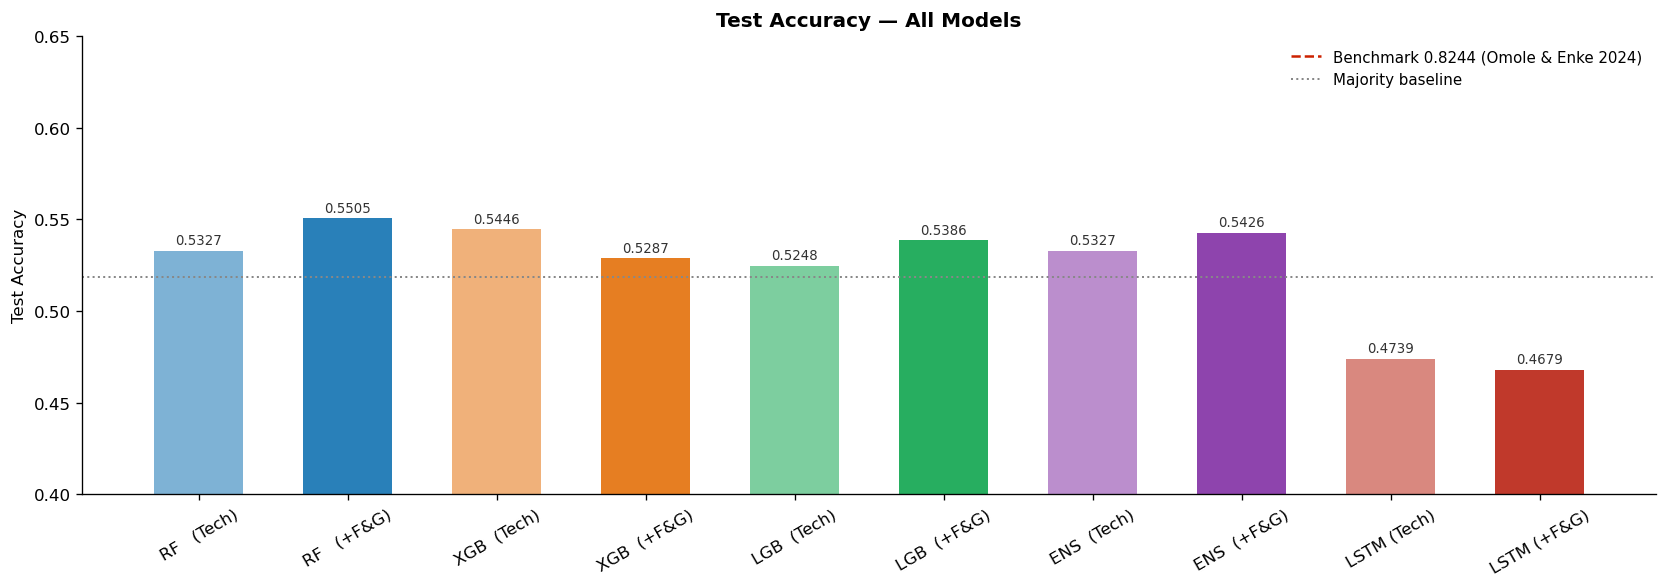

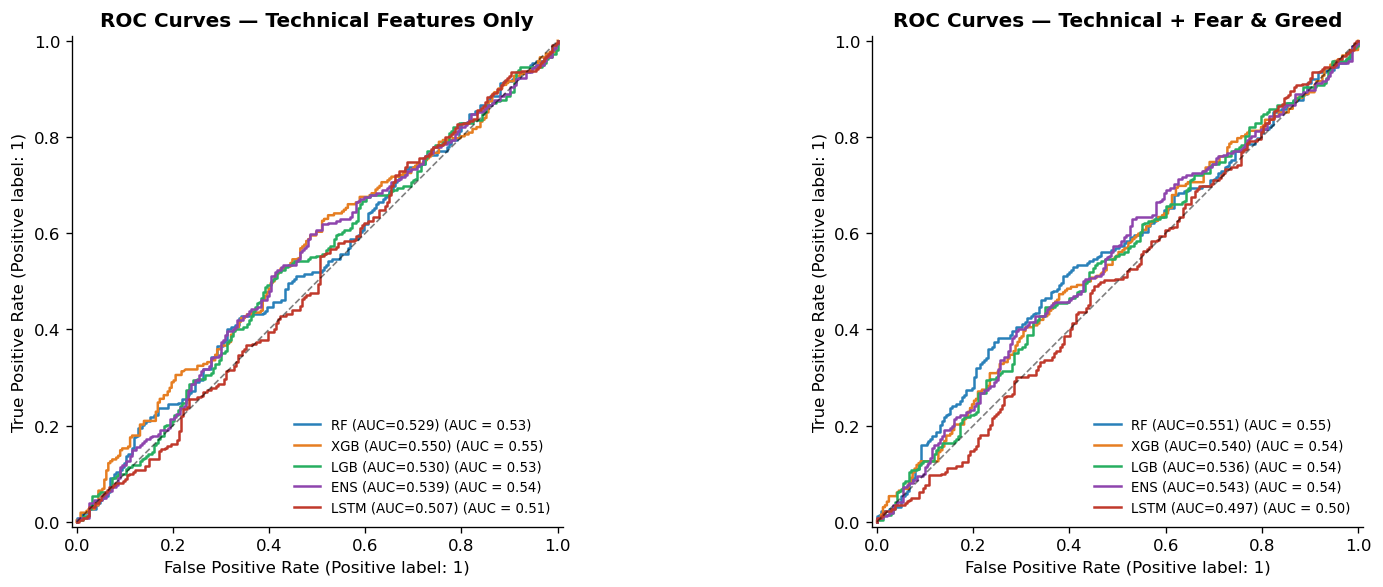

In [45]:
# ── Results Table ─────────────────────────────────────────────
_results = []
for _name, _pred, _proba, _y in [
    ("RF   (Tech)",  rf_pred,    rf_proba,    y_ts_main),
    ("RF   (+F&G)",  rfs_pred,   rfs_proba,   y_ts_main),
    ("XGB  (Tech)",  xgb_pred,   xgb_proba,   y_ts_main),
    ("XGB  (+F&G)",  xgbs_pred,  xgbs_proba,  y_ts_main),
    ("LGB  (Tech)",  lgb_pred,   lgb_proba,   y_ts_main),
    ("LGB  (+F&G)",  lgbs_pred,  lgbs_proba,  y_ts_main),
    ("ENS  (Tech)",  ens_pred,   ens_proba,   y_ts_main),
    ("ENS  (+F&G)",  enss_pred,  enss_proba,  y_ts_main),
    ("LSTM (Tech)",  lstm_pred,  lp,          y_ts_l),
    ("LSTM (+F&G)",  lstms_pred, lsp,         y_ts_l),
]:
    _results.append({
        "Model": _name,
        "Acc":   round(accuracy_score(_y, _pred), 4),
        "Prec":  round(precision_score(_y, _pred, zero_division=0), 4),
        "Rec":   round(recall_score(_y, _pred, zero_division=0), 4),
        "F1":    round(f1_score(_y, _pred, zero_division=0), 4),
        "AUC":   round(roc_auc_score(_y, _proba), 4),
    })

df_results = pd.DataFrame(_results)
print(df_results.to_string(index=False))
print(f"\nBenchmark (Omole & Enke 2024): {BENCH_ACC}")
print(f"Majority baseline:             {max(y_ts_main.mean(), 1-y_ts_main.mean()):.4f}")
df_results.to_csv("outputs/model_results.csv", index=False)

# ── Bar Chart ─────────────────────────────────────────────────
_colors = ["#2980b9","#2980b9","#e67e22","#e67e22",
           "#27ae60","#27ae60","#8e44ad","#8e44ad",
           "#c0392b","#c0392b"]
_alphas = [0.6, 1.0, 0.6, 1.0, 0.6, 1.0, 0.6, 1.0, 0.6, 1.0]

fig, ax = plt.subplots(figsize=(14, 5), facecolor="none")
ax.set_facecolor("none")
_bars = ax.bar(df_results["Model"], df_results["Acc"],
               color=_colors, alpha=0.85, width=0.6)
for _bar, _a in zip(_bars, _alphas):
    _bar.set_alpha(_a)
for _bar, _val in zip(_bars, df_results["Acc"]):
    ax.text(_bar.get_x() + _bar.get_width()/2,
            _bar.get_height() + 0.002,
            f"{_val:.4f}", ha="center", va="bottom",
            fontsize=8, color="#333")
ax.axhline(BENCH_ACC, color=RED, linestyle="--", lw=1.5,
           label=f"Benchmark {BENCH_ACC} (Omole & Enke 2024)")
ax.axhline(max(y_ts_main.mean(), 1-y_ts_main.mean()),
           color=GRAY, linestyle=":", lw=1.2,
           label=f"Majority baseline")
ax.set_ylabel("Test Accuracy")
ax.set_ylim(0.4, max(df_results["Acc"].max() + 0.05, 0.65))
ax.set_title("Test Accuracy — All Models", fontweight="bold")
ax.legend(fontsize=9, framealpha=0)
ax.tick_params(axis="x", rotation=30)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/model_accuracy.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

# ── ROC Curves ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="none")

for ax, _title, _models in zip(axes, [
    "Technical Features Only",
    "Technical + Fear & Greed"
], [
    [("RF",   rf_proba,    y_ts_main, "#2980b9"),
     ("XGB",  xgb_proba,   y_ts_main, "#e67e22"),
     ("LGB",  lgb_proba,   y_ts_main, "#27ae60"),
     ("ENS",  ens_proba,   y_ts_main, "#8e44ad"),
     ("LSTM", lp,          y_ts_l,    "#c0392b")],
    [("RF",   rfs_proba,   y_ts_main, "#2980b9"),
     ("XGB",  xgbs_proba,  y_ts_main, "#e67e22"),
     ("LGB",  lgbs_proba,  y_ts_main, "#27ae60"),
     ("ENS",  enss_proba,  y_ts_main, "#8e44ad"),
     ("LSTM", lsp,         y_ts_l,    "#c0392b")],
]):
    ax.set_facecolor("none")
    for _name, _proba, _y, _col in _models:
        RocCurveDisplay.from_predictions(
            _y, _proba, name=f"{_name} (AUC={roc_auc_score(_y,_proba):.3f})",
            ax=ax, color=_col, lw=1.5)
    ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5)
    ax.set_title(f"ROC Curves — {_title}", fontweight="bold")
    ax.legend(fontsize=8, framealpha=0, loc="lower right")
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("outputs/roc_curves.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

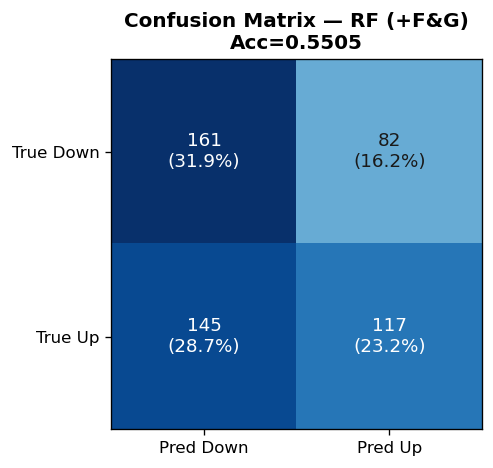

In [46]:
# ── Confusion Matrix — Best Model (RF +F&G) ───────────────────
_cm = confusion_matrix(y_ts_main, rfs_pred)

fig, ax = plt.subplots(figsize=(5, 4), facecolor="none")
ax.set_facecolor("none")
ax.imshow(_cm, cmap="Blues", vmin=0, vmax=_cm.max())

for i in range(2):
    for j in range(2):
        _val = _cm[i, j]
        _pct = _val / _cm.sum() * 100
        ax.text(j, i, f"{_val}\n({_pct:.1f}%)",
                ha="center", va="center", fontsize=11,
                color="white" if _val > _cm.max()*0.6 else "#1a1a1a")

ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred Down", "Pred Up"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["True Down", "True Up"])
ax.set_title(f"Confusion Matrix — RF (+F&G)\nAcc={RF_S_ACC:.4f}",
             fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_best.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

Bootstrap CI  |  N=5000  |  95% Percentile Interval
Model                 Acc               95% CI      AUC               95% CI
────────────────────────────────────────────────────────────────────────────
RF   (Tech)        0.5327 [0.4891, 0.5762]    0.5291 [0.4798, 0.5773]
RF   (+F&G)        0.5505 [0.5069, 0.5960]    0.5513 [0.5016, 0.6022]
XGB  (Tech)        0.5446 [0.5030, 0.5881]    0.5500 [0.5020, 0.6003]
XGB  (+F&G)        0.5287 [0.4851, 0.5743]    0.5395 [0.4878, 0.5906]
LGB  (Tech)        0.5248 [0.4812, 0.5683]    0.5298 [0.4795, 0.5792]
LGB  (+F&G)        0.5386 [0.4931, 0.5822]    0.5363 [0.4857, 0.5869]
ENS  (Tech)        0.5327 [0.4891, 0.5782]    0.5390 [0.4898, 0.5898]
ENS  (+F&G)        0.5426 [0.4990, 0.5861]    0.5427 [0.4926, 0.5940]
LSTM (Tech)        0.4739 [0.4297, 0.5181]    0.5066 [0.4567, 0.5579]
LSTM (+F&G)        0.4679 [0.4237, 0.5120]    0.4969 [0.4445, 0.5495]


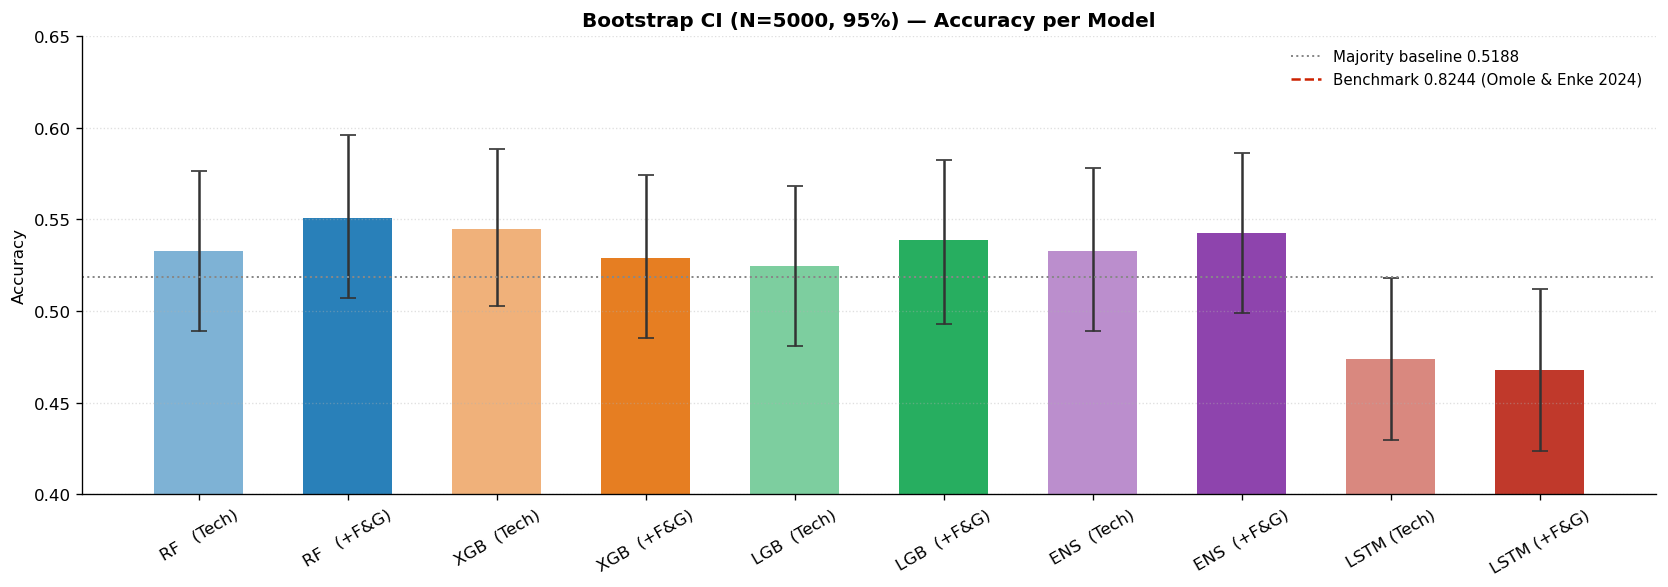

In [47]:
N_BOOT = 5000
RNG    = np.random.default_rng(SEED)

def _boot_ci(y_true, y_pred, y_proba, n=N_BOOT):
    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_proba = np.array(y_proba)
    acc_b, f1_b, auc_b = [], [], []
    idx_pool = np.arange(len(y_true))
    for _ in range(n):
        idx = RNG.choice(idx_pool, len(idx_pool), replace=True)
        acc_b.append(accuracy_score(y_true[idx], y_pred[idx]))
        f1_b.append(f1_score(y_true[idx], y_pred[idx], zero_division=0))
        auc_b.append(roc_auc_score(y_true[idx], y_proba[idx]))
    return {
        "Acc":    accuracy_score(y_true, y_pred),
        "Acc_lo": np.percentile(acc_b, 2.5),
        "Acc_hi": np.percentile(acc_b, 97.5),
        "F1":     f1_score(y_true, y_pred, zero_division=0),
        "F1_lo":  np.percentile(f1_b, 2.5),
        "F1_hi":  np.percentile(f1_b, 97.5),
        "AUC":    roc_auc_score(y_true, y_proba),
        "AUC_lo": np.percentile(auc_b, 2.5),
        "AUC_hi": np.percentile(auc_b, 97.5),
    }

_models_boot = [
    ("RF   (Tech)", rf_pred,    rf_proba,    y_ts_main),
    ("RF   (+F&G)", rfs_pred,   rfs_proba,   y_ts_main),
    ("XGB  (Tech)", xgb_pred,   xgb_proba,   y_ts_main),
    ("XGB  (+F&G)", xgbs_pred,  xgbs_proba,  y_ts_main),
    ("LGB  (Tech)", lgb_pred,   lgb_proba,   y_ts_main),
    ("LGB  (+F&G)", lgbs_pred,  lgbs_proba,  y_ts_main),
    ("ENS  (Tech)", ens_pred,   ens_proba,   y_ts_main),
    ("ENS  (+F&G)", enss_pred,  enss_proba,  y_ts_main),
    ("LSTM (Tech)", lstm_pred,  lp,          y_ts_l),
    ("LSTM (+F&G)", lstms_pred, lsp,         y_ts_l),
]

boot_results = {}
print(f"Bootstrap CI  |  N={N_BOOT}  |  95% Percentile Interval")
print(f"{'Model':<16} {'Acc':>8} {'95% CI':>20} "
      f"{'AUC':>8} {'95% CI':>20}")
print("─" * 76)

for _name, _pred, _proba, _y in _models_boot:
    r = _boot_ci(_y, _pred, _proba)
    boot_results[_name] = r
    print(f"{_name:<16} {r['Acc']:>8.4f} "
          f"[{r['Acc_lo']:.4f}, {r['Acc_hi']:.4f}]  "
          f"{r['AUC']:>8.4f} "
          f"[{r['AUC_lo']:.4f}, {r['AUC_hi']:.4f}]")

# ── Chart ─────────────────────────────────────────────────────
_names  = [m[0] for m in _models_boot]
_accs   = [boot_results[n]["Acc"]    for n in _names]
_lo     = [boot_results[n]["Acc"] - boot_results[n]["Acc_lo"] for n in _names]
_hi     = [boot_results[n]["Acc_hi"] - boot_results[n]["Acc"] for n in _names]
_colors = ["#2980b9","#2980b9","#e67e22","#e67e22",
           "#27ae60","#27ae60","#8e44ad","#8e44ad",
           "#c0392b","#c0392b"]
_alphas = [0.6,1.0,0.6,1.0,0.6,1.0,0.6,1.0,0.6,1.0]

fig, ax = plt.subplots(figsize=(14, 5), facecolor="none")
ax.set_facecolor("none")
bars = ax.bar(_names, _accs, color=_colors, alpha=0.85,
              width=0.6, yerr=[_lo, _hi],
              capsize=5, error_kw={"elinewidth":1.5,"ecolor":"#333"})
for bar, a in zip(bars, _alphas):
    bar.set_alpha(a)
ax.axhline(max(y_ts_main.mean(), 1-y_ts_main.mean()),
           color=GRAY, linestyle=":", lw=1.2,
           label=f"Majority baseline {max(y_ts_main.mean(), 1-y_ts_main.mean()):.4f}")
ax.axhline(BENCH_ACC, color=RED, linestyle="--", lw=1.5,
           label=f"Benchmark {BENCH_ACC} (Omole & Enke 2024)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.4, 0.65)
ax.set_title(f"Bootstrap CI (N={N_BOOT}, 95%) — Accuracy per Model",
             fontweight="bold")
ax.legend(fontsize=9, framealpha=0)
ax.tick_params(axis="x", rotation=30)
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/bootstrap_ci.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

── Top 15 Features by Mean |SHAP| ───────────────────
Ret_L1          0.0854
Vol_30          0.0742
ATR             0.0662
FG_sentiment    0.0577
ADX             0.0568
Ret_L30         0.0492
Ret_L21         0.0475
Ret_L5          0.0430
BB_width        0.0352
Ret_L14         0.0342
Stoch_K         0.0281
ADX_neg         0.0264
Vol_spike       0.0259
Price_MA30      0.0253
Vol_spike_7     0.0246

FG_sentiment rank: #4/40


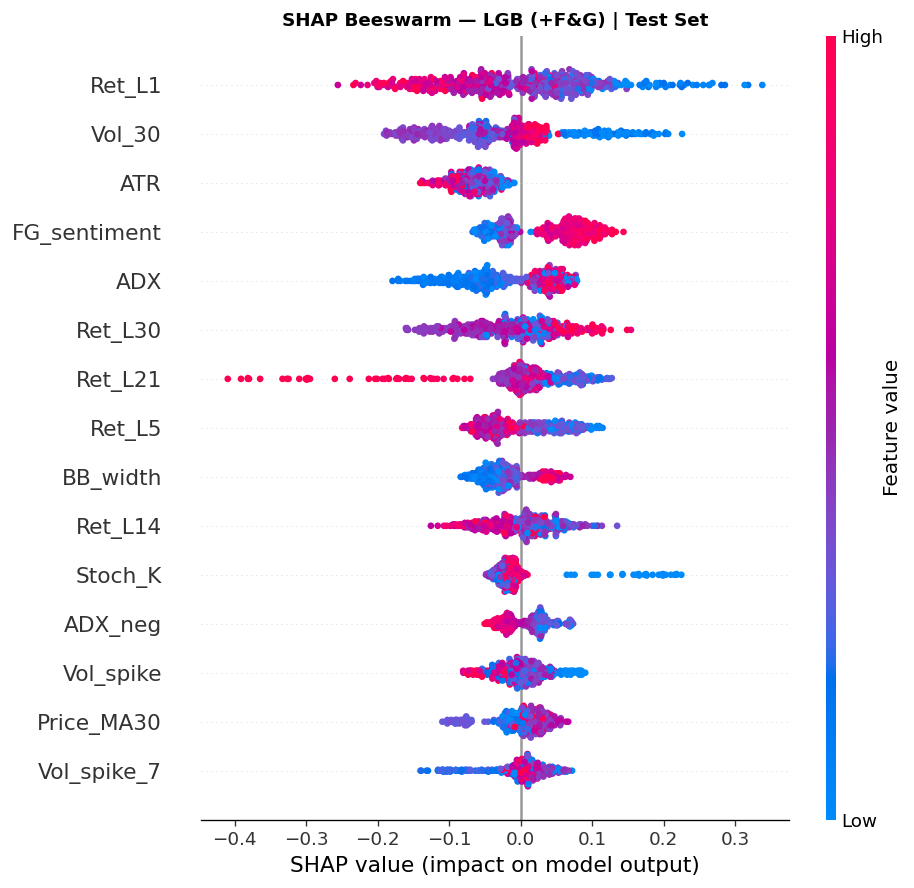

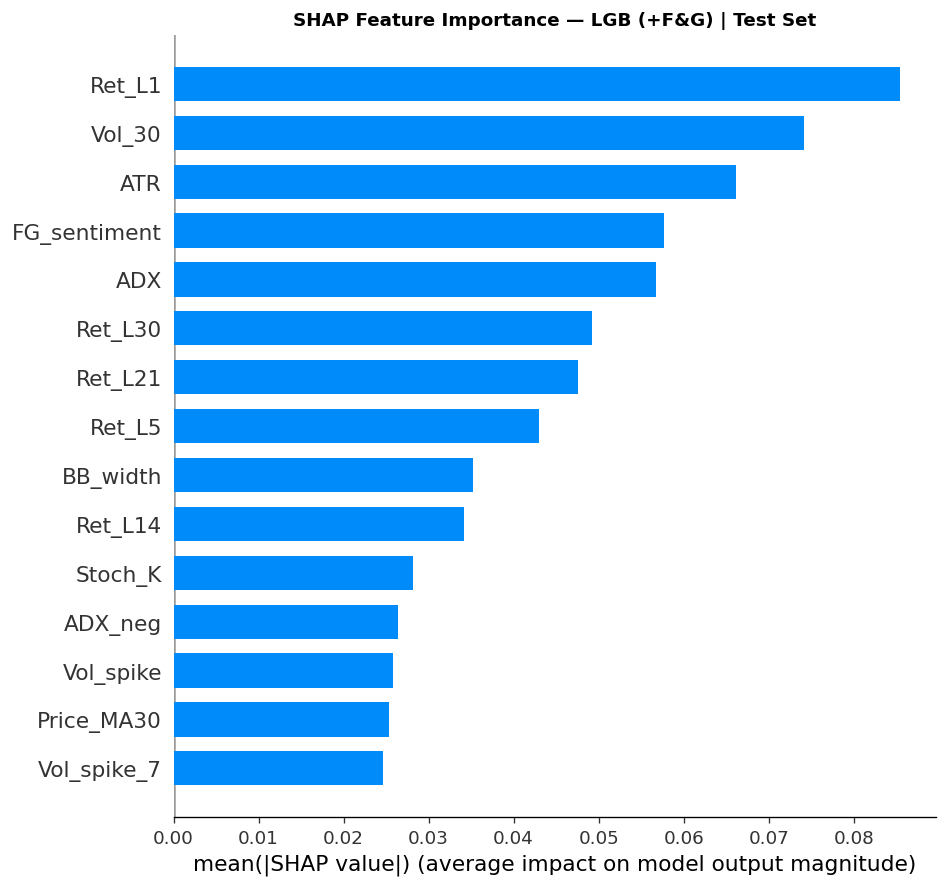

In [48]:
import shap

# ── SHAP Explainer ────────────────────────────────────────────
explainer  = shap.TreeExplainer(lgb_s)
shap_vals  = explainer.shap_values(X_fg_ts_sc)

# LGB TreeExplainer gibt Liste zurück [class0, class1]
# Klasse 1 (Up) nehmen
if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals

# In DataFrame für bessere Lesbarkeit
shap_df = pd.DataFrame(sv, columns=FEAT_FG)

# ── Mean |SHAP| pro Feature ───────────────────────────────────
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
print("── Top 15 Features by Mean |SHAP| ───────────────────")
print(mean_abs_shap.head(15).round(4).to_string())
print(f"\nFG_sentiment rank: #{mean_abs_shap.rank(ascending=False)['FG_sentiment']:.0f}/40")

# ── Beeswarm Plot ─────────────────────────────────────────────
shap.summary_plot(
    sv,
    X_fg_ts_sc,
    feature_names=FEAT_FG,
    max_display=15,
    show=False,
    plot_type="dot"
)
plt.title("SHAP Beeswarm — LGB (+F&G) | Test Set",
          fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/shap_beeswarm.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

# ── Bar Plot (Mean |SHAP|) ────────────────────────────────────
shap.summary_plot(
    sv,
    X_fg_ts_sc,
    feature_names=FEAT_FG,
    max_display=15,
    show=False,
    plot_type="bar"
)
plt.title("SHAP Feature Importance — LGB (+F&G) | Test Set",
          fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("outputs/shap_bar.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

In [49]:
# ── Dataset Summary ───────────────────────────────────────────
print(f"{'Dataset':<24} {'Train':>6} {'Test':>6} {'Period'}")
print("─" * 65)
print(f"{'Main (Tech+FG)':<24} {split_idx:>6} "
      f"{len(df_clean)-split_idx:>6}  "
      f"{df_clean.index[0].date()} → {df_clean.index[-1].date()}")
print(f"{'Overlap (Tech+FG)':<24} {split_idx_ol:>6} "
      f"{len(df_ol)-split_idx_ol:>6}  "
      f"{df_ol.index[0].date()} → {df_ol.index[-1].date()}")
print(f"{'Overlap (Tech+VADER)':<24} {split_idx_ol:>6} "
      f"{len(df_ol)-split_idx_ol:>6}  "
      f"{df_ol.index[0].date()} → {df_ol.index[-1].date()}")

# ── Hyperparameter Verification ───────────────────────────────
print("\nSame Optuna-optimized hyperparameters across all experiments:")
_skip = {"random_state","verbose","n_jobs","eval_metric","verbosity"}
for _m, _p in best_params.items():
    print(f"  {_m}: { {k:v for k,v in _p.items() if k not in _skip} }")

# ── F&G vs VADER Comparison (Overlap Period Only) ─────────────
print(f"\n{'Model':<12} {'F&G Acc':>9} {'F&G F1':>8} {'F&G AUC':>9} "
      f"{'VADER Acc':>10} {'VADER F1':>9} {'VADER AUC':>10} "
      f"{'ΔAcc':>8}")
print("─" * 80)

for _name, _fg_pred, _fg_proba, _vad_pred, _vad_proba, _y in [
    ("RF",   rf_ol_fg_pred,  rf_ol_fg_proba,  rf_ol_pred,   rf_ol_proba,   y_ol_ts),
    ("XGB",  xgb_ol_fg_pred, xgb_ol_fg_proba, xgb_ol_pred,  xgb_ol_proba,  y_ol_ts),
    ("LGB",  lgb_ol_fg_pred, lgb_ol_fg_proba, lgb_ol_pred,  lgb_ol_proba,  y_ol_ts),
    ("ENS",  ens_ol_fg_pred, ens_ol_fg_proba, ens_ol_pred,  ens_ol_proba,  y_ol_ts),
]:
    _fg_acc  = accuracy_score(_y, _fg_pred)
    _fg_f1   = f1_score(_y, _fg_pred, zero_division=0)
    _fg_auc  = roc_auc_score(_y, _fg_proba)
    _vad_acc = accuracy_score(_y, _vad_pred)
    _vad_f1  = f1_score(_y, _vad_pred, zero_division=0)
    _vad_auc = roc_auc_score(_y, _vad_proba)
    _delta   = (_vad_acc - _fg_acc) * 100
    print(f"{_name:<12} {_fg_acc:>9.4f} {_fg_f1:>8.4f} {_fg_auc:>9.4f} "
          f"{_vad_acc:>10.4f} {_vad_f1:>9.4f} {_vad_auc:>10.4f} "
          f"{_delta:>+7.2f}pp")

# ── Delta Summary ─────────────────────────────────────────────
print(f"\n{'Model':<12} {'ΔAcc':>8} {'ΔF1':>8} {'ΔAUC':>8} {'Winner':>8}")
print("─" * 44)
for _name, _fg_pred, _fg_proba, _vad_pred, _vad_proba, _y in [
    ("RF",  rf_ol_fg_pred,  rf_ol_fg_proba,  rf_ol_pred,  rf_ol_proba,  y_ol_ts),
    ("XGB", xgb_ol_fg_pred, xgb_ol_fg_proba, xgb_ol_pred, xgb_ol_proba, y_ol_ts),
    ("LGB", lgb_ol_fg_pred, lgb_ol_fg_proba, lgb_ol_pred, lgb_ol_proba, y_ol_ts),
    ("ENS", ens_ol_fg_pred, ens_ol_fg_proba, ens_ol_pred, ens_ol_proba, y_ol_ts),
]:
    _da = (accuracy_score(_y,_vad_pred) - accuracy_score(_y,_fg_pred))*100
    _df = (f1_score(_y,_vad_pred,zero_division=0) - f1_score(_y,_fg_pred,zero_division=0))*100
    _du = (roc_auc_score(_y,_vad_proba) - roc_auc_score(_y,_fg_proba))*100
    _w  = "VADER" if _da > 0 else "F&G"
    print(f"{_name:<12} {_da:>+7.2f}pp {_df:>+7.2f}pp {_du:>+7.2f}pp {_w:>8}")

Dataset                   Train   Test Period
─────────────────────────────────────────────────────────────────
Main (Tech+FG)             2017    505  2018-02-04 → 2024-12-30
Overlap (Tech+FG)           708    178  2021-11-06 → 2024-09-12
Overlap (Tech+VADER)        708    178  2021-11-06 → 2024-09-12

Same Optuna-optimized hyperparameters across all experiments:
  RF: {'n_estimators': 356, 'max_depth': 8, 'min_samples_leaf': 19, 'max_features': 'sqrt'}
  XGB: {'n_estimators': 347, 'max_depth': 3, 'learning_rate': 0.08212056072736397, 'subsample': 0.6066021130363833, 'colsample_bytree': 0.5172432011622204, 'gamma': 4.739826606530733, 'reg_alpha': 6.599127973372474, 'reg_lambda': 7.921587169314106}
  LGB: {'max_depth': 5, 'n_estimators': 290, 'num_leaves': 24, 'learning_rate': 0.015901953990975288, 'subsample': 0.5733941271990494, 'colsample_bytree': 0.6887178552328633, 'min_child_samples': 84, 'reg_alpha': 3.233479485009171, 'reg_lambda': 7.281553948859293}

Model          F&G Acc   F

NameError: name 'rf_ol_fg_pred' is not defined

In [ ]:
np.random.seed(SEED)

# ── Threshold Optimization on Validation (no bias) ────────────
_val_size   = int(len(X_fg_tr_sc) * 0.20)
_val_X      = X_fg_tr_sc[-_val_size:]
_val_y      = y_tr[-_val_size:]
_val_proba  = rf_s.predict_proba(_val_X)[:,1]

_thresholds = np.arange(0.30, 0.71, 0.05)
_best_thr   = max(_thresholds,
    key=lambda t: accuracy_score(_val_y, (_val_proba>t).astype(int)))
print(f"Optimized threshold (validation): {_best_thr:.2f}")

# ── Returns & Transaction Costs ───────────────────────────────
TC   = 0.001  # 0.1% per trade
_ret = pd.Series(ret_ts)

def _apply_tc(signals, returns, tc=TC):
    """Apply transaction costs on position changes."""
    signals  = pd.Series(signals)
    returns  = pd.Series(returns)
    _changes = signals.diff().abs().fillna(0)
    _net     = signals * returns - _changes * tc
    return _net

# ── Strategy Signals ──────────────────────────────────────────
_sig_default    = (rfs_proba > 0.50).astype(int)
_sig_optimized  = (rfs_proba > _best_thr).astype(int)
_sig_confidence = (rfs_proba > 0.60).astype(int)
_sig_bh         = np.ones(len(ret_ts), dtype=int)
_sig_random     = np.random.choice([1, 0, -1], size=len(ret_ts))

# ── Trading Metrics ───────────────────────────────────────────
def trading_metrics(signals, returns, label, tc=TC):
    _net  = _apply_tc(signals, returns, tc)
    _cum  = (1 + _net).cumprod()
    _tot  = _cum.iloc[-1] - 1
    _sr   = _net.mean() / _net.std() * np.sqrt(252) if _net.std() > 0 else 0
    _neg  = _net[_net < 0]
    _so   = _net.mean() / _neg.std() * np.sqrt(252) if len(_neg)>0 else 0
    _roll = _cum.cummax()
    _mdd  = (((_cum - _roll) / _roll).min())
    _wr   = (_net > 0).mean()
    _n_trades = (pd.Series(signals).diff().abs() > 0).sum()
    return {
        "Strategy":   label,
        "Total Ret":  f"{_tot:.2%}",
        "Sharpe":     f"{_sr:.3f}",
        "Sortino":    f"{_so:.3f}",
        "Max DD":     f"{_mdd:.2%}",
        "Win Rate":   f"{_wr:.2%}",
        "N Trades":   int(_n_trades),
        "_cum":       _cum,
        "_tot":       _tot,
        "_sr":        _sr,
    }

_strategies = [
    (_sig_default,    f"Model (Default 0.50)"),
    (_sig_optimized,  f"Model (Optimized {_best_thr:.2f})"),
    (_sig_confidence, f"Model (Confidence 0.60)"),
    (_sig_bh,         "Buy & Hold"),
    (_sig_random,     "Random"),
]

_results = [trading_metrics(s, _ret, l) for s, l in _strategies]

# ── Print Results ─────────────────────────────────────────────
print(f"\n{'Strategy':<26} {'Total Ret':>10} {'Sharpe':>8} "
      f"{'Sortino':>8} {'Max DD':>8} {'Win Rate':>9} {'N Trades':>9}")
print("─" * 82)
for r in _results:
    print(f"{r['Strategy']:<26} {r['Total Ret']:>10} {r['Sharpe']:>8} "
          f"{r['Sortino']:>8} {r['Max DD']:>8} {r['Win Rate']:>9} "
          f"{r['N Trades']:>9}")

# ── Cumulative Returns Chart ───────────────────────────────────
_colors = [RED, "#e67e22", "#8e44ad", "#2980b9", GRAY]
_styles = ["-", "--", "-.", ":", ":"]

fig, ax = plt.subplots(figsize=(14, 5), facecolor="none")
ax.set_facecolor("none")

for r, col, ls in zip(_results, _colors, _styles):
    ax.plot(test_dates, r["_cum"].values,
            color=col, lw=1.8 if "Model" in r["Strategy"] else 1.2,
            linestyle=ls, label=f"{r['Strategy']} ({r['Total Ret']})")

ax.axhline(1.0, color=GRAY, lw=0.8, linestyle=":")
ax.set_ylabel("Cumulative Return (1 = Initial Investment)")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_title("Cumulative Returns — Trading Strategy Comparison (2023–2024)",
             fontweight="bold")
ax.legend(fontsize=9, framealpha=0, loc="upper left")
ax.spines[["top","right"]].set_visible(False)
ax.yaxis.grid(True, linestyle=":", alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("outputs/trading_strategy.png", dpi=150,
            bbox_inches="tight", transparent=True)
plt.show(); plt.close()

In [ ]:
def _train(ModelClass, params, X_tr, y_tr, X_ts, y_ts):
    m     = ModelClass(**params)
    m.fit(X_tr, y_tr)
    pred  = m.predict(X_ts)
    proba = m.predict_proba(X_ts)[:,1]
    return (m, pred, proba,
            accuracy_score(y_ts, pred),
            precision_score(y_ts, pred, zero_division=0),
            recall_score(y_ts, pred, zero_division=0),
            f1_score(y_ts, pred, zero_division=0),
            roc_auc_score(y_ts, proba))

# ── Random Forest ─────────────────────────────────────────────
(rf,  rf_pred,  rf_proba,
 RF_ACC,  RF_PREC,  RF_REC,  RF_F1,  RF_AUC)  = _train(
    RandomForestClassifier, best_params["RF"],
    X_tech_tr_sc, y_tr, X_tech_ts_sc, y_ts_main)

(rf_s, rfs_pred, rfs_proba,
 RF_S_ACC, RF_S_PREC, RF_S_REC, RF_S_F1, RF_S_AUC) = _train(
    RandomForestClassifier, best_params["RF"],
    X_fg_tr_sc, y_tr, X_fg_ts_sc, y_ts_main)

# ── XGBoost ───────────────────────────────────────────────────
(xgb_m, xgb_pred, xgb_proba,
 XGB_ACC,  XGB_PREC,  XGB_REC,  XGB_F1,  XGB_AUC)  = _train(
    xgb.XGBClassifier, best_params["XGB"],
    X_tech_tr_sc, y_tr, X_tech_ts_sc, y_ts_main)

(xgb_s, xgbs_pred, xgbs_proba,
 XGB_S_ACC, XGB_S_PREC, XGB_S_REC, XGB_S_F1, XGB_S_AUC) = _train(
    xgb.XGBClassifier, best_params["XGB"],
    X_fg_tr_sc, y_tr, X_fg_ts_sc, y_ts_main)

# ── LightGBM ──────────────────────────────────────────────────
(lgb_m, lgb_pred, lgb_proba,
 LGB_ACC,  LGB_PREC,  LGB_REC,  LGB_F1,  LGB_AUC)  = _train(
    lgb.LGBMClassifier, best_params["LGB"],
    X_tech_tr_sc, y_tr, X_tech_ts_sc, y_ts_main)

(lgb_s, lgbs_pred, lgbs_proba,
 LGB_S_ACC, LGB_S_PREC, LGB_S_REC, LGB_S_F1, LGB_S_AUC) = _train(
    lgb.LGBMClassifier, best_params["LGB"],
    X_fg_tr_sc, y_tr, X_fg_ts_sc, y_ts_main)

# ── Voting Ensemble ───────────────────────────────────────────
ens = VotingClassifier([("rf",rf),("xgb",xgb_m),("lgb",lgb_m)],
                        voting="soft", n_jobs=-1)
ens.fit(X_tech_tr_sc, y_tr)
ens_pred  = ens.predict(X_tech_ts_sc)
ens_proba = ens.predict_proba(X_tech_ts_sc)[:,1]
ENS_ACC   = accuracy_score(y_ts_main,  ens_pred)
ENS_PREC  = precision_score(y_ts_main, ens_pred, zero_division=0)
ENS_REC   = recall_score(y_ts_main,   ens_pred, zero_division=0)
ENS_F1    = f1_score(y_ts_main,       ens_pred, zero_division=0)
ENS_AUC   = roc_auc_score(y_ts_main,  ens_proba)

ens_s = VotingClassifier([("rf",rf_s),("xgb",xgb_s),("lgb",lgb_s)],
                          voting="soft", n_jobs=-1)
ens_s.fit(X_fg_tr_sc, y_tr)
enss_pred  = ens_s.predict(X_fg_ts_sc)
enss_proba = ens_s.predict_proba(X_fg_ts_sc)[:,1]
ENS_S_ACC  = accuracy_score(y_ts_main,  enss_pred)
ENS_S_PREC = precision_score(y_ts_main, enss_pred, zero_division=0)
ENS_S_REC  = recall_score(y_ts_main,   enss_pred, zero_division=0)
ENS_S_F1   = f1_score(y_ts_main,       enss_pred, zero_division=0)
ENS_S_AUC  = roc_auc_score(y_ts_main,  enss_proba)

In [ ]:
# ── RF (Tech + VADER) ─────────────────────────────────────────
(rf_ol, rf_ol_pred, rf_ol_proba,
 RF_OL_ACC, RF_OL_PREC, RF_OL_REC, RF_OL_F1, RF_OL_AUC) = _train(
    RandomForestClassifier, best_params["RF"],
    X_ol_tr_sc, y_ol_tr, X_ol_ts_sc, y_ol_ts)

# ── XGB (Tech + VADER) ────────────────────────────────────────
(xgb_ol, xgb_ol_pred, xgb_ol_proba,
 XGB_OL_ACC, XGB_OL_PREC, XGB_OL_REC, XGB_OL_F1, XGB_OL_AUC) = _train(
    xgb.XGBClassifier, best_params["XGB"],
    X_ol_tr_sc, y_ol_tr, X_ol_ts_sc, y_ol_ts)

# ── LGB (Tech + VADER) ────────────────────────────────────────
(lgb_ol, lgb_ol_pred, lgb_ol_proba,
 LGB_OL_ACC, LGB_OL_PREC, LGB_OL_REC, LGB_OL_F1, LGB_OL_AUC) = _train(
    lgb.LGBMClassifier, best_params["LGB"],
    X_ol_tr_sc, y_ol_tr, X_ol_ts_sc, y_ol_ts)

# ── Voting Ensemble (Tech + VADER) ────────────────────────────
ens_ol = VotingClassifier(
    [("rf", rf_ol), ("xgb", xgb_ol), ("lgb", lgb_ol)],
    voting="soft", n_jobs=-1)
ens_ol.fit(X_ol_tr_sc, y_ol_tr)
ens_ol_pred  = ens_ol.predict(X_ol_ts_sc)
ens_ol_proba = ens_ol.predict_proba(X_ol_ts_sc)[:,1]
ENS_OL_ACC   = accuracy_score(y_ol_ts,  ens_ol_pred)
ENS_OL_PREC  = precision_score(y_ol_ts, ens_ol_pred, zero_division=0)
ENS_OL_REC   = recall_score(y_ol_ts,   ens_ol_pred, zero_division=0)
ENS_OL_F1    = f1_score(y_ol_ts,       ens_ol_pred, zero_division=0)
ENS_OL_AUC   = roc_auc_score(y_ol_ts,  ens_ol_proba)

In [ ]:
LSTM_JSON = "outputs/lstm_best_params.json"

def make_seqs(X, y, w):
    return (np.array([X[i-w:i] for i in range(w, len(X))]),
            np.array(y[w:]))

def build_lstm(window, n_feat, units1, units2, dropout, lr):
    tf.random.set_seed(SEED)
    m = Sequential([
        KerasLSTM(units1, return_sequences=True,
                  input_shape=(window, n_feat)),
        BatchNormalization(), Dropout(dropout),
        KerasLSTM(units2),
        BatchNormalization(), Dropout(dropout),
        Dense(32, activation="relu"), Dropout(dropout/2),
        Dense(1, activation="sigmoid")
    ])
    m.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0),
              loss="binary_crossentropy", metrics=["accuracy"])
    return m

if os.path.exists(LSTM_JSON):
    with open(LSTM_JSON) as f:
        lstm_best = json.load(f)
else:
    def lstm_obj(trial):
        window  = trial.suggest_categorical("window",[3,5,7,10,14,21])
        units1  = trial.suggest_categorical("units1",[64,128,256])
        units2  = trial.suggest_categorical("units2",[32,64,128])
        dropout = trial.suggest_float("dropout",0.1,0.4)
        lr      = trial.suggest_float("lr",1e-4,1e-2,log=True)
        batch   = trial.suggest_categorical("batch_size",[16,32,64])
        tscv3   = TimeSeriesSplit(n_splits=3)
        scores  = []
        for tr_idx, va_idx in tscv3.split(X_tech_tr_sc):
            if len(X_tech_tr_sc[tr_idx]) < window+10: return 0.5
            X_seq_tr, y_seq_tr = make_seqs(X_tech_tr_sc[tr_idx],
                                            y_tr[tr_idx], window)
            X_comb = np.concatenate([X_tech_tr_sc[tr_idx][-window:],
                                      X_tech_tr_sc[va_idx]])
            y_comb = np.concatenate([y_tr[tr_idx][-window:],y_tr[va_idx]])
            X_seq_va, y_seq_va = make_seqs(X_comb, y_comb, window)
            m = build_lstm(window, X_tech_tr_sc.shape[1],
                            units1, units2, dropout, lr)
            m.fit(X_seq_tr, y_seq_tr, epochs=30, batch_size=batch,
                  validation_data=(X_seq_va, y_seq_va),
                  callbacks=[EarlyStopping(patience=5,
                             restore_best_weights=True, verbose=0)],
                  verbose=0)
            proba = m.predict(X_seq_va, verbose=0).flatten()
            scores.append(accuracy_score(y_seq_va,
                          (proba > 0.5).astype(int)))
            del m; tf.keras.backend.clear_session()
        return np.mean(scores)

    print("Optimizing LSTM (20 trials)...")
    _ls = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=SEED))
    _ls.optimize(lstm_obj, n_trials=20, show_progress_bar=False)
    lstm_best = {**_ls.best_params, "cv_acc": _ls.best_value}
    with open(LSTM_JSON,"w") as f:
        json.dump(lstm_best, f, indent=2)

WINDOW   = lstm_best["window"]
units1   = lstm_best["units1"]
units2   = lstm_best["units2"]
dropout  = lstm_best["dropout"]
lr       = lstm_best["lr"]
batch_sz = lstm_best["batch_size"]

X_tr_l,  y_tr_l  = make_seqs(X_tech_tr_sc, y_tr,      WINDOW)
X_ts_l,  y_ts_l  = make_seqs(X_tech_ts_sc, y_ts_main, WINDOW)
Xs_tr_l, _       = make_seqs(X_fg_tr_sc,   y_tr,      WINDOW)
Xs_ts_l, _       = make_seqs(X_fg_ts_sc,   y_ts_main, WINDOW)
test_dates_lstm   = test_dates[WINDOW:]
ret_ts_lstm       = ret_ts[WINDOW:]

cbs = [EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
       ReduceLROnPlateau(patience=7, factor=0.5, verbose=0)]

# ── LSTM (Technical) ──────────────────────────────────────────
lstm_tech = build_lstm(WINDOW, len(FEAT), units1, units2, dropout, lr)
lstm_tech.fit(X_tr_l, y_tr_l, epochs=120, batch_size=batch_sz,
              validation_split=0.15, callbacks=cbs, verbose=0)
lp        = lstm_tech.predict(X_ts_l, verbose=0).flatten()
lstm_pred = (lp > 0.5).astype(int)
LSTM_ACC  = accuracy_score(y_ts_l,  lstm_pred)
LSTM_PREC = precision_score(y_ts_l, lstm_pred, zero_division=0)
LSTM_REC  = recall_score(y_ts_l,   lstm_pred, zero_division=0)
LSTM_F1   = f1_score(y_ts_l,       lstm_pred, zero_division=0)
LSTM_AUC  = roc_auc_score(y_ts_l,  lp)

# ── LSTM (Technical + F&G) ────────────────────────────────────
lstm_fg = build_lstm(WINDOW, len(FEAT_FG), units1, units2, dropout, lr)
lstm_fg.fit(Xs_tr_l, y_tr_l, epochs=120, batch_size=batch_sz,
             validation_split=0.15, callbacks=cbs, verbose=0)
lsp        = lstm_fg.predict(Xs_ts_l, verbose=0).flatten()
lstms_pred = (lsp > 0.5).astype(int)
LSTM_S_ACC  = accuracy_score(y_ts_l,  lstms_pred)
LSTM_S_PREC = precision_score(y_ts_l, lstms_pred, zero_division=0)
LSTM_S_REC  = recall_score(y_ts_l,   lstms_pred, zero_division=0)
LSTM_S_F1   = f1_score(y_ts_l,       lstms_pred, zero_division=0)
LSTM_S_AUC  = roc_auc_score(y_ts_l,  lsp)

In [ ]:
X_ol_tr_l, y_ol_tr_l = make_seqs(X_ol_tr_sc, y_ol_tr, WINDOW)
X_ol_ts_l, y_ol_ts_l = make_seqs(X_ol_ts_sc, y_ol_ts, WINDOW)
test_dates_ol_lstm    = test_dates_ol[WINDOW:]
ret_ts_ol_lstm        = ret_ts_ol[WINDOW:]

lstm_ol = build_lstm(WINDOW, len(FEAT_VADER),
                     units1, units2, dropout, lr)
lstm_ol.fit(X_ol_tr_l, y_ol_tr_l, epochs=120, batch_size=batch_sz,
            validation_split=0.15, callbacks=cbs, verbose=0)

lp_ol        = lstm_ol.predict(X_ol_ts_l, verbose=0).flatten()
lstm_ol_pred = (lp_ol > 0.5).astype(int)

LSTM_OL_ACC  = accuracy_score(y_ol_ts_l,  lstm_ol_pred)
LSTM_OL_PREC = precision_score(y_ol_ts_l, lstm_ol_pred, zero_division=0)
LSTM_OL_REC  = recall_score(y_ol_ts_l,   lstm_ol_pred, zero_division=0)
LSTM_OL_F1   = f1_score(y_ol_ts_l,       lstm_ol_pred, zero_division=0)
LSTM_OL_AUC  = roc_auc_score(y_ol_ts_l,  lp_ol)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 · MODEL EVALUATION — Accuracy, F1, AUC, Precision, Recall
# ═══════════════════════════════════════════════════════════════
_results = []
for _name, _pred, _proba, _y in [
    ("RF   (Tech)", rf_pred,    rf_proba,    y_ts_main),
    ("RF   (+F&G)", rfs_pred,   rfs_proba,   y_ts_main),
    ("XGB  (Tech)", xgb_pred,   xgb_proba,   y_ts_main),
    ("XGB  (+F&G)", xgbs_pred,  xgbs_proba,  y_ts_main),
    ("LGB  (Tech)", lgb_pred,   lgb_proba,   y_ts_main),
    ("LGB  (+F&G)", lgbs_pred,  lgbs_proba,  y_ts_main),
    ("ENS  (Tech)", ens_pred,   ens_proba,   y_ts_main),
    ("ENS  (+F&G)", enss_pred,  enss_proba,  y_ts_main),
    ("LSTM (Tech)", lstm_pred,  lp,          y_ts_l),
    ("LSTM (+F&G)", lstms_pred, lsp,         y_ts_l),
]:
    _results.append({
        "Model":  _name,
        "Acc":    round(accuracy_score(_y,_pred),4),
        "Prec":   round(precision_score(_y,_pred,zero_division=0),4),
        "Rec":    round(recall_score(_y,_pred,zero_division=0),4),
        "F1":     round(f1_score(_y,_pred,zero_division=0),4),
        "AUC":    round(roc_auc_score(_y,_proba),4),
    })

df_results = pd.DataFrame(_results)
print(df_results.to_string(index=False))
print(f"\nBenchmark (Omole & Enke 2024): {BENCH_ACC}")
df_results.to_csv("outputs/model_results.csv", index=False)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 · FEATURE IMPORTANCE — RF, XGB, LGB
# Normalized [0,1] | FG_sentiment highlighted
# ═══════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches

_names = FEAT_FG.copy()

def _get_fi(model, feat_names, mname):
    if mname == "RF":
        _s = pd.Series(model.feature_importances_, index=feat_names)
    elif mname == "XGB":
        _raw = model.get_booster().get_score(importance_type="gain")
        _s   = pd.Series(0.0, index=feat_names)
        for k, v in _raw.items():
            if k.startswith("f") and k[1:].isdigit():
                idx = int(k[1:])
                if idx < len(feat_names): _s.iloc[idx] = v
            elif k in feat_names: _s[k] = v
    else:
        _s = pd.Series(
            model.booster_.feature_importance(importance_type="gain"),
            index=feat_names)
    return _s / _s.max() if _s.max() > 0 else _s

_fi_rf  = _get_fi(rf_s,  _names, "RF")
_fi_xgb = _get_fi(xgb_s, _names, "XGB")
_fi_lgb = _get_fi(lgb_s, _names, "LGB")

_sent_ranks = {
    "RF":  int(_fi_rf.rank(ascending=False)["FG_sentiment"]),
    "XGB": int(_fi_xgb.rank(ascending=False)["FG_sentiment"]),
    "LGB": int(_fi_lgb.rank(ascending=False)["FG_sentiment"]),
}

N_TOP = 15
_SENT = "#CC2200"
fig, axes = plt.subplots(1, 3, figsize=(16, 7), facecolor="none")
fig.suptitle(
    f"Feature Importance | Top {N_TOP} of {len(_names)} | "
    "Normalized [0,1] | FEAT + Fear & Greed",
    fontsize=11, fontweight="bold", y=1.01)

for ax, (fi, title, color, mk) in zip(axes, [
    (_fi_rf,  "Random Forest\n(Gini/MDI)",  "#2980b9", "RF"),
    (_fi_xgb, "XGBoost\n(Gain)",             "#e67e22", "XGB"),
    (_fi_lgb, "LightGBM\n(Gain)",            "#27ae60", "LGB"),
]):
    ax.set_facecolor("none")
    top = fi.nlargest(N_TOP).sort_values(ascending=True)
    ax.barh(range(N_TOP), top.values,
            color=[_SENT if f=="FG_sentiment" else color for f in top.index],
            alpha=0.88, edgecolor="white", height=0.72)
    for i,(v,f) in enumerate(zip(top.values,top.index)):
        ax.text(v+0.015,i,f"{v:.3f}",va="center",fontsize=8,
                color=_SENT if f=="FG_sentiment" else GRAY)
    ax.set_yticks(range(N_TOP)); ax.set_yticklabels(top.index,fontsize=9)
    for tick,f in zip(ax.get_yticklabels(),top.index):
        if f=="FG_sentiment": tick.set_color(_SENT); tick.set_fontweight("bold")
    ax.set_xlim(0,1.20)
    ax.set_xlabel("Normalized Importance [0,1]",fontsize=10)
    ax.set_title(f"{title}\nFG rank #{_sent_ranks[mk]}/{len(_names)}",
                 fontsize=10,fontweight="bold",color=color,pad=8)
    ax.spines[["top","right","left"]].set_visible(False)
    ax.tick_params(axis="y",length=0)
    ax.xaxis.grid(True,linestyle=":",alpha=0.35)
    ax.set_axisbelow(True)

fig.legend(handles=[
    mpatches.Patch(color="#2980b9",label="RF"),
    mpatches.Patch(color="#e67e22",label="XGB"),
    mpatches.Patch(color="#27ae60",label="LGB"),
    mpatches.Patch(color=_SENT,    label="FG_sentiment"),
], loc="lower center",ncol=4,fontsize=9,
   framealpha=0.0,bbox_to_anchor=(0.5,-0.04))

plt.tight_layout()
plt.savefig("outputs/feature_importance.png",dpi=150,
            bbox_inches="tight",transparent=True)
plt.show(); plt.close()

In [ ]:
import os, json

# Schritt 1: Check was in best_params.json steht
if os.path.exists("outputs/best_params.json"):
    with open("outputs/best_params.json") as f:
        print(json.load(f))
else:
    print("Datei existiert nicht")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 · STATISTICAL VALIDATION — McNemar + Bootstrap
# ═══════════════════════════════════════════════════════════════
from scipy.stats import binom

# McNemar (continuity-corrected Z-test)
def _mcnemar(p1, p2, y):
    b = np.sum((p1==1)&(p2==0)&(y==1)) + np.sum((p1==0)&(p2==1)&(y==0))
    c = np.sum((p1==0)&(p2==1)&(y==1)) + np.sum((p1==1)&(p2==0)&(y==0))
    n = b + c
    if n < 20:
        T = min(b,c)
        p = 2*binom.cdf(T,n,0.5)
    else:
        z = (abs(b-c)-1)/np.sqrt(b+c)
        from scipy.stats import norm
        p = 2*(1-norm.cdf(z))
    return b, c, round(p,4)

_pairs = [
    ("RF","LGB",   rf_pred,  lgb_pred),
    ("XGB","LGB",  xgb_pred, lgb_pred),
    ("ENS","LGB",  ens_pred, lgb_pred),
    ("RF+S","LGB+S",rfs_pred,lgbs_pred),
    ("XGB+S","LGB+S",xgbs_pred,lgbs_pred),
]
print(f"{'Pair':<20} {'n12':>5} {'n21':>5} {'p':>8} {'sig':>5}")
print("─"*45)
for _a, _b, _pa, _pb in _pairs:
    b,c,p = _mcnemar(_pa,_pb,y_ts_main)
    print(f"{_a+' vs '+_b:<20} {b:>5} {c:>5} {p:>8.4f} "
          f"{'*' if p<0.05 else ''}")

# Bootstrap CI
N_BOOT = 2000
RNG    = np.random.default_rng(SEED)

def _boot_ci(y_true, y_pred, y_proba):
    acc_b, auc_b = [], []
    n = len(y_true)
    for _ in range(N_BOOT):
        idx = RNG.choice(n, n, replace=True)
        acc_b.append(accuracy_score(y_true[idx], y_pred[idx]))
        auc_b.append(roc_auc_score(y_true[idx], y_proba[idx]))
    return (np.percentile(acc_b,[2.5,97.5]),
            np.percentile(auc_b,[2.5,97.5]))

print(f"\n{'Model':<12} {'Acc':>8} {'95% CI Acc':>20} {'AUC':>8} {'95% CI AUC':>20}")
print("─"*72)
for _name, _pred, _proba, _y in [
    ("RF",   rf_pred,  rf_proba,  y_ts_main),
    ("XGB",  xgb_pred, xgb_proba, y_ts_main),
    ("LGB",  lgb_pred, lgb_proba, y_ts_main),
    ("ENS",  ens_pred, ens_proba, y_ts_main),
    ("LSTM", lstm_pred,lp,        y_ts_l),
]:
    _pred   = np.array(_pred)
    _proba  = np.array(_proba)
    _y      = np.array(_y)
    acc_ci, auc_ci = _boot_ci(_y,_pred,_proba)
    print(f"{_name:<12} {accuracy_score(_y,_pred):>8.4f} "
          f"[{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]  "
          f"{roc_auc_score(_y,_proba):>8.4f} "
          f"[{auc_ci[0]:.4f}, {auc_ci[1]:.4f}]")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 18 · TRADING STRATEGY EVALUATION
# Model signal vs Buy & Hold vs Random
# ═══════════════════════════════════════════════════════════════
def trading_metrics(signals, returns, label):
    port  = signals * returns
    cum   = (1 + port).cumprod()
    total = cum.iloc[-1] - 1
    sr    = port.mean() / port.std() * np.sqrt(252)
    neg   = port[port < 0]
    so    = port.mean() / neg.std() * np.sqrt(252) if len(neg)>0 else np.nan
    roll_max = cum.cummax()
    mdd   = ((cum - roll_max) / roll_max).min()
    wr    = (port > 0).mean()
    return {"Model":label,"Total Ret":f"{total:.2%}",
            "Sharpe":f"{sr:.3f}","Sortino":f"{so:.3f}",
            "Max DD":f"{mdd:.2%}","Win Rate":f"{wr:.2%}"}

_ret_s = pd.Series(ret_ts)

_rows = []
for _label, _sig in [
    ("RF",   rf_pred),
    ("XGB",  xgb_pred),
    ("LGB",  lgb_pred),
    ("ENS",  ens_pred),
    ("Buy & Hold", np.ones(len(ret_ts))),
    ("Random",     np.random.choice([0,1],size=len(ret_ts))),
]:
    _sig_s = pd.Series(np.where(np.array(_sig)==1,1,-1))
    _rows.append(trading_metrics(_sig_s, _ret_s, _label))

print(pd.DataFrame(_rows).to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 19 · OVERLAP DATASET — BTC + VADER (2021–2024)
# ═══════════════════════════════════════════════════════════════
_vader_lagged = (daily_vader[["VADER_sentiment"]]
                 .shift(1).rename(columns={"VADER_sentiment":"VADER_sentiment"}))

df_ol = (df[FEAT + ["FG_sentiment","LogReturn","Direction"]]
         .join(_vader_lagged, how="inner")
         .dropna())

FEAT_VADER = FEAT + ["VADER_sentiment"]
FEAT_FG_OL = FEAT + ["FG_sentiment"]

_split_ol = int(len(df_ol)*0.80)

_sc_ol_tech = StandardScaler()
_sc_ol_fg   = StandardScaler()
_sc_ol_vad  = StandardScaler()

_X_ol_tech_tr = _sc_ol_tech.fit_transform(df_ol[FEAT].values[:_split_ol])
_X_ol_tech_ts = _sc_ol_tech.transform(df_ol[FEAT].values[_split_ol:])
_X_ol_fg_tr   = _sc_ol_fg.fit_transform(df_ol[FEAT_FG_OL].values[:_split_ol])
_X_ol_fg_ts   = _sc_ol_fg.transform(df_ol[FEAT_FG_OL].values[_split_ol:])
_X_ol_vad_tr  = _sc_ol_vad.fit_transform(df_ol[FEAT_VADER].values[:_split_ol])
_X_ol_vad_ts  = _sc_ol_vad.transform(df_ol[FEAT_VADER].values[_split_ol:])

_y_ol_tr = df_ol["Direction"].values[:_split_ol]
_y_ol_ts = df_ol["Direction"].values[_split_ol:]

print(f"Overlap: {len(df_ol):,} rows | "
      f"{df_ol.index[0].date()} → {df_ol.index[-1].date()} | "
      f"Train={_split_ol} Test={len(df_ol)-_split_ol}")

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 20 · OVERLAP BASELINE MODELS — RF, XGB, LGB
# FEAT | FEAT+FG | FEAT+VADER on 2021-2024 overlap period
# ═══════════════════════════════════════════════════════════════
_baseline_models = {}
_baseline_results = []

_FEAT_CFGS = [
    ("FEAT",       FEAT,       _X_ol_tech_tr, _X_ol_tech_ts, None),
    ("FEAT+FG",    FEAT_FG_OL, _X_ol_fg_tr,   _X_ol_fg_ts,   "FG_sentiment"),
    ("FEAT+VADER", FEAT_VADER, _X_ol_vad_tr,  _X_ol_vad_ts,  "VADER_sentiment"),
]

for _fname, _feats, _Xtr, _Xts, _sent in _FEAT_CFGS:
    for _mname, _cls, _p in [
        ("RF",  RandomForestClassifier, best_params["RF"]),
        ("XGB", xgb.XGBClassifier,      best_params["XGB"]),
        ("LGB", lgb.LGBMClassifier,     best_params["LGB"]),
    ]:
        _key = f"{_mname}_{_fname}_baseline"
        _m   = _cls(**_p)
        _m.fit(_Xtr, _y_ol_tr)
        _pred  = _m.predict(_Xts)
        _proba = _m.predict_proba(_Xts)[:,1]
        _acc   = accuracy_score(_y_ol_ts, _pred)
        _f1    = f1_score(_y_ol_ts, _pred)
        _baseline_models[_key] = _m
        _baseline_results.append({"Model":_mname,"Features":_fname,
                                   "Acc":round(_acc,4),"F1":round(_f1,4)})

print(pd.DataFrame(_baseline_results).to_string(index=False))

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 21 · FINAL MODEL COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════
print(df_results.to_string(index=False))
print(f"\nBenchmark: {BENCH_ACC} (Omole & Enke 2024 — contextual ref. only)")
print(f"\nBest model: {df_results.loc[df_results['Acc'].idxmax(),'Model']} "
      f"Acc={df_results['Acc'].max():.4f}")